# Google drive mount

In [ ]:
# 계정 드라이브와 마운트하기
# 모두 선택해서 동의해야 마운트가 오류없이 됩니다.
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


# 파일 가져오기

In [ ]:
!ls /content/drive/MyDrive/Kaggle01

rokey-boot-camp-mini-competition.zip


In [4]:
!unzip /content/drive/MyDrive/Kaggle01/rokey-boot-camp-mini-competition.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/train_data/00000.png  
  inflating: data/train_data/00001.png  
  inflating: data/train_data/00002.png  
  inflating: data/train_data/00003.png  
  inflating: data/train_data/00004.png  
  inflating: data/train_data/00005.png  
  inflating: data/train_data/00006.png  
  inflating: data/train_data/00007.png  
  inflating: data/train_data/00008.png  
  inflating: data/train_data/00009.png  
  inflating: data/train_data/00010.png  
  inflating: data/train_data/00011.png  
  inflating: data/train_data/00012.png  
  inflating: data/train_data/00013.png  
  inflating: data/train_data/00014.png  
  inflating: data/train_data/00015.png  
  inflating: data/train_data/00016.png  
  inflating: data/train_data/00017.png  
  inflating: data/train_data/00018.png  
  inflating: data/train_data/00019.png  
  inflating: data/train_data/00020.png  
  inflating: data/train_data/00021.png  
  inflating: data/train_data/00022.png  
  infl

In [6]:
!ls data

test_data  train_data  train_data.csv


# 파일 구조 확인

In [7]:
!ls data/train_data

00000.png  00715.png  01430.png  02145.png  02860.png  03575.png  04290.png
00001.png  00716.png  01431.png  02146.png  02861.png  03576.png  04291.png
00002.png  00717.png  01432.png  02147.png  02862.png  03577.png  04292.png
00003.png  00718.png  01433.png  02148.png  02863.png  03578.png  04293.png
00004.png  00719.png  01434.png  02149.png  02864.png  03579.png  04294.png
00005.png  00720.png  01435.png  02150.png  02865.png  03580.png  04295.png
00006.png  00721.png  01436.png  02151.png  02866.png  03581.png  04296.png
00007.png  00722.png  01437.png  02152.png  02867.png  03582.png  04297.png
00008.png  00723.png  01438.png  02153.png  02868.png  03583.png  04298.png
00009.png  00724.png  01439.png  02154.png  02869.png  03584.png  04299.png
00010.png  00725.png  01440.png  02155.png  02870.png  03585.png  04300.png
00011.png  00726.png  01441.png  02156.png  02871.png  03586.png  04301.png
00012.png  00727.png  01442.png  02157.png  02872.png  03587.png  04302.png
00013.png  0

In [8]:
!ls data/test_data

00000.png  01143.png  02286.png  03429.png  04572.png  05715.png  06858.png
00001.png  01144.png  02287.png  03430.png  04573.png  05716.png  06859.png
00002.png  01145.png  02288.png  03431.png  04574.png  05717.png  06860.png
00003.png  01146.png  02289.png  03432.png  04575.png  05718.png  06861.png
00004.png  01147.png  02290.png  03433.png  04576.png  05719.png  06862.png
00005.png  01148.png  02291.png  03434.png  04577.png  05720.png  06863.png
00006.png  01149.png  02292.png  03435.png  04578.png  05721.png  06864.png
00007.png  01150.png  02293.png  03436.png  04579.png  05722.png  06865.png
00008.png  01151.png  02294.png  03437.png  04580.png  05723.png  06866.png
00009.png  01152.png  02295.png  03438.png  04581.png  05724.png  06867.png
00010.png  01153.png  02296.png  03439.png  04582.png  05725.png  06868.png
00011.png  01154.png  02297.png  03440.png  04583.png  05726.png  06869.png
00012.png  01155.png  02298.png  03441.png  04584.png  05727.png  06870.png
00013.png  0

In [ ]:
# 첫 10개의 학습 데이터 이름과 label 출력
import pandas as pd
train_df = pd.read_csv("data/train_data.csv")
train_df.head(10)

,label,name
0,1,00000.png
1,5,00001.png
2,1,00002.png
3,6,00003.png
4,3,00004.png
5,9,00005.png
6,7,00006.png
7,4,00007.png
8,5,00008.png
9,8,00009.png


In [1]:
# 각 파일마다 라벨이 무엇인지 나타내는 dictionary 생성
name2label = dict(zip(train_df["name"], train_df["label"]))
print(name2label['03501.png'])

# glob 라이브러리로 훈련데이터에 있는 파일 리스트 출력
import os
data_path = "data"
from glob import glob
glob(f"{data_path}/train_data/*.png")

NameError: name 'train_df' is not defined

# DataLoader

압축푼 직후에는 파일적용이 되지 않아 FileNotFoundError 오류가 뜰 수 있습니다.

그러한 경우 약간의 대기 시간 이후 다시 실행하면 됩니다.

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.transforms import v2

import time
from PIL import Image
from tqdm import tqdm
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

torch version: 2.13.0+cu132
cuda available: True
torch cuda version: 13.2
device count: 1


In [3]:
# 랜덤성 제어를 위한 seed 고정
import random
import numpy as np

seed = 0
deterministic = True

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
if deterministic:
	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = False

In [4]:
from glob import glob
import os

# 커스텀 데이터셋 클래스
class MyDataset(Dataset):
    def __init__(self, data_path, transform=None, train=True):
        self.train = train
        train_df = pd.read_csv(f"{data_path}/train_data.csv")

        self.name2label = dict(zip(train_df["name"], train_df["label"]))

        if self.train:
            self.img_path = glob(f"{data_path}/train_data/*.png")
            # self.labels =  [self.name2label[d.split("/")[-1]] for d in self.img_path]
            self.labels =  [self.name2label[os.path.basename(d)] for d in self.img_path]
        else:
            self.img_path = glob(f"{data_path}/test_data/*.png")

        self.transform = transform

    def __len__(self):
        return len(self.img_path)   

    def __getitem__(self, index):
        img = Image.open(self.img_path[index])
        if img.mode != 'RGB':
            img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        if self.train:
            return img, self.labels[index]
        else:
            return img, self.img_path[index].split("/")[-1]

In [5]:
# 데이터셋 디렉토리 위치 지정
data_path = "./data"

In [6]:

train_total_dataset_temp = MyDataset(data_path, train=True, transform=v2.ToTensor())

# Split train data into train and validation
data_size = len(train_total_dataset_temp)
train_size = int(len(train_total_dataset_temp) * 0.9)
val_size = data_size - train_size
generator = torch.Generator().manual_seed(seed)
train_indices, val_indices = torch.utils.data.random_split(range(data_size), [train_size, val_size], generator = generator)


train_datset_for_stats = Subset(train_total_dataset_temp, train_indices)
channel_sum = torch.zeros(3)
channel_sqred_sum = torch.zeros(3)
classes = {i : 0 for i in range(10)}
for image, label in train_datset_for_stats:
    # print(image.shape)
    channel_sum += image.sum(dim = (1, 2))
    channel_sqred_sum += (image**2).sum(dim = (1, 2))
    classes[label] += 1
    
num_pixels = 96*96*4500
mean = channel_sum / num_pixels
var = channel_sqred_sum / num_pixels - mean ** 2
std = torch.sqrt(var)

print("mean:", mean)
print("std:", std)
# print(train_total_dataset_temp[0])

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


mean: tensor([0.4460, 0.4393, 0.4073])
std: tensor([0.2608, 0.2569, 0.2717])


In [7]:
'''
데이터 전처리
    - transform.Compose에 전처리할 순서를 차례로 지정한 후 리스트 형태로 입력하여 데이터 생성시 설정한 전처리를 적용
    - 여러 가지의 데이터 증강 기법이 들어감
'''
# train_transform_m =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomResizedCrop(224),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.ColorJitter(brightness = 0.2, contrast = 0.2),
#     v2.ToTensor(),
#     v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
# ])

# train_transform_m =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.Resize((224, 224)),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.ToTensor(),
#     v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
# ])

# train_transform_st =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomResizedCrop((224, 224)),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.RandomRotation(15),
#     v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
#     v2.ToTensor(),
#     v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
# ])

# test_transform =  transforms.Compose([
#     v2.Resize((224, 224)),
#     v2.ToTensor(),
#     v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
# ])

train_transform_m =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=4),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.ToTensor(),
    v2.Normalize(mean = mean, std = std),
])

train_transform_st =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=4),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.Normalize(mean = mean, std = std),
])

test_transform =  transforms.Compose([
    v2.ToTensor(),
    v2.Normalize(mean = mean, std = std),
])

train_total_dataset_m = MyDataset(data_path, train=True, transform=train_transform_m)
train_total_dataset_st =  MyDataset(data_path, train=True, transform=train_transform_st)
val_dataset =  MyDataset(data_path, train=True, transform=test_transform)
test_data = MyDataset(data_path, train=False, transform=test_transform)

# train_data_m, val_data = torch.utils.data.random_split(train_dataset_m, [train_size, len(train_dataset_m) - train_size])


train_data_m = Subset(train_total_dataset_m, train_indices)
train_data_st = Subset(train_total_dataset_st, train_indices)
train_data_eavl_for_mix = Subset(val_dataset, train_indices)
val_data = Subset(val_dataset, val_indices)

In [8]:
print(classes)

{0: 456, 1: 448, 2: 462, 3: 444, 4: 447, 5: 447, 6: 440, 7: 448, 8: 454, 9: 454}


In [9]:
train_loader_m = torch.utils.data.DataLoader(train_data_m, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle=False)

In [10]:
print(train_data_m[0])
print(len(train_data_m))

(tensor([[[-0.4471, -0.1012,  0.3500,  ..., -1.7103, -1.7103, -1.7103],
         [-0.5674, -0.5373, -0.1613,  ..., -1.7103, -1.7103, -1.7103],
         [-0.4019, -0.0861,  0.1545,  ..., -1.7103, -1.7103, -1.7103],
         ...,
         [-1.7103, -1.7103, -1.7103,  ..., -1.7103, -1.7103, -1.7103],
         [-1.7103, -1.7103, -1.7103,  ..., -1.7103, -1.7103, -1.7103],
         [-1.7103, -1.7103, -1.7103,  ..., -1.7103, -1.7103, -1.7103]],

        [[-0.0767,  0.1981,  0.3813,  ..., -1.7100, -1.7100, -1.7100],
         [-0.2293, -0.1835,  0.1218,  ..., -1.7100, -1.7100, -1.7100],
         [ 0.0454,  0.1370,  0.2744,  ..., -1.7100, -1.7100, -1.7100],
         ...,
         [-1.7100, -1.7100, -1.7100,  ..., -1.7100, -1.7100, -1.7100],
         [-1.7100, -1.7100, -1.7100,  ..., -1.7100, -1.7100, -1.7100],
         [-1.7100, -1.7100, -1.7100,  ..., -1.7100, -1.7100, -1.7100]],

        [[-0.9651, -0.9940, -0.8785,  ..., -1.4993, -1.4993, -1.4993],
         [-1.1672, -1.2683, -1.2250,  ..., -

# Model

In [11]:
from torchvision.models import resnet18

# Torchvision 라이브러리에서 모델 불러오기
def make_model(change_conv = False):
    model = resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    if change_conv: # 모델 해상도 향상 7x7 stride 1=> 3x3 stride = 2
        model.conv1 = nn.Conv2d(3, 64, kernel_size = 3, stride = 2, padding = 1, bias = False)
        # model.maxpool = nn.Identity()

    model = model.to(device)
    return model

In [12]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):

        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        # self.val_loss_min = np.inf
        self.best_dict = None
        self.best_epoch = 0

    def __call__(self, val_loss, model, epoch):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_dict = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch + 1
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} / {self.patience}')
            if score > self.best_score:
                self.best_score = score
                self.best_dict = copy.deepcopy(model.state_dict())
                self.best_epoch = epoch + 1
            
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_dict = copy.deepcopy(model.state_dict())
            self.counter = 0
            self.best_epoch = epoch + 1

# # Early Stopping 객체 생성
# early_stopping = EarlyStopping(patience=5, delta=0.001)
# print('Early Stopping 설정 완료')

In [13]:
def validate(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
def validate_tta(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0
    tta_running_loss = 0

    correct = 0
    tta_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            inputs_flipped = torch.flip(inputs, dims = [3])
            outputs_flipped = model(inputs_flipped)

            outputs_tta = (outputs_flipped + outputs) / 2

            loss = criterion(outputs, labels)
            tta_loss = criterion(outputs_tta, labels)

            running_loss += loss.item() * inputs.size(0)
            tta_running_loss += tta_loss.item() * inputs.size(0)
            predicted = outputs.argmax(1)
            predicted_tta = outputs_tta.argmax(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            tta_correct += (predicted_tta == labels).sum().item()

    epoch_val_loss = running_loss / total
    epoch_val_acc = correct / total
    epoch_tta_loss = tta_running_loss / total
    epoch_tta_acc = tta_correct / total

    return epoch_val_loss, epoch_val_acc, epoch_tta_loss, epoch_tta_acc

In [13]:
# criterion = nn.CrossEntropyLoss(label_smoothing = 0.1) # 바꿔보기
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9) # 바꿔보기
# num_epochs = 50 # 바꿔보기
# base_lr = 1e-3
# sched = optim.lr_scheduler.OneCycleLR(
#     optimizer,
#        max_lr=lr * 10,  # 최대 학습률
#         epochs=num_epochs,
#         steps_per_epoch=len(train_loader),
#         pct_start=0.3,
#         anneal_strategy='cos',
#         div_factor=10,
#         final_div_factor=100
#         )

In [ ]:
# def run(dataset = "mid", lr=1e-3, batch_size=64, optimizer='adam', weight_decay = 1e-6, epochs=5, verbose=False): # verbose=False 출력
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed) # to make same model

#     model = make_model()
#     if dataset == "mid":
#         tl = DataLoader(train_data_m, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#     else:
#         tl = DataLoader(train_data_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

#     vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

#     if optimizer == 'adam':
#         opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
#     else :
#         opt =  torch.optim.SGD(model.parameters(), lr=lr,  momentum = 0.9, weight_decay = weight_decay)

#     # opt = {'adam': torch.optim.Adam, 'sgd': torch.optim.SGD}[optimizer](model.parameters(), 
#     #                                                                     lr=lr, weight_decay = weight_decay)
#     # opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay = weight_decay)
#     # opt = torch.optim.SGD(model.parameters(), lr=1e-2, momentum = 0.9, weight_decay = 1e-4)
#     # tl = DataLoader(train_data_m, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#     # opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)
#     crit = nn.CrossEntropyLoss()
#     # sched = optim.lr_scheduler.OneCycleLR(
#     #     opt,
#     #     max_lr=lr * 10,  # 최대 학습률
#     #     epochs=epochs,
#     #     steps_per_epoch=len(tl),
#     #     pct_start=0.3,
#     #     anneal_strategy='cos',
#     #     div_factor=10,
#     #     final_div_factor=100
#     #     )
    
#     early_stopping = EarlyStopping(patience=5, delta=0.001)
    
#     for ep in tqdm(range(epochs)):
#         model.train()

#         train_running_loss = 0.0
#         train_correct = 0
#         train_total = 0

#         train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

#         start = time.perf_counter()
        
#         for x, y in train_bar:
#             x, y = x.to(device), y.to(device)
            
#             opt.zero_grad(); 

#             outputs = model(x)
#             loss = crit(outputs, y); 

#             loss.backward(); 
#             opt.step(); 
#             # sched.step()

#         # =========================
#         # Train metric 누적
#         # =========================

#             train_running_loss += loss.item() * x.size(0)

#             predicted = outputs.argmax(dim=1)

#             train_correct += (predicted == y).sum().item()
#             train_total += y.size(0)

#         train_loss = train_running_loss / train_total
#         train_acc = train_correct / train_total

#     # CUDA 연산 완료까지 기다린 뒤 정확한 시간 측정
#         # if device.type == "cuda":
#         #     torch.cuda.synchronize()

#         print(
#             # f"\nTrain 완료: "{time.perf_counter() - start:.2f}초 | "
#             f"\nTrain 완료"
#             f"loss={train_loss:.4f} | "
#             f"acc={train_acc:.4f}"
#         )
#         # ------------------------
#         # Validation 시간
#         # ------------------------
#         # start = time.perf_counter()
#         # print("Validation 시작")


#         model.eval(); 
        
#         correct = total = 0
#         val_loss, val_acc = validate(model, vl, crit, device)

#         if device.type == "cuda":
#             torch.cuda.synchronize()

#         print(
#             # f"Validation 완료: {time.perf_counter() - start:.2f}초 | "
#             f"\nValidation 완료"
#             f"loss={val_loss:.4f} | acc={val_acc:.4f}"
#         )


#         if verbose:
#             print(
#                 f"epoch {ep+1:2d} | "
#                 f"val_loss={val_loss:.4f} | "
#                 f"val_acc={val_acc:.4f}"
#             )

#         early_stopping(val_loss, model, ep)

#         if early_stopping.early_stop:
#             print("조기 종료 되었습니다.")
#             print(f"Early stopping : {early_stopping.best_epoch} / {epochs}")
#             break
            
#     model.load_state_dict(early_stopping.best_dict)
#     final_val_loss, final_val_acc = validate( model, vl, crit, device)

#     return final_val_acc, final_val_loss

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     dataset        = trial.suggest_categorical('transform', ["mid", "strong"])
#     opt          = trial.suggest_categorical('optimizer', ['adam', 'sgd'])
#     if opt == "adam":
#         lr = trial.suggest_float("lr", 2e-4, 2e-3, log=True)

#     else:
#         lr = trial.suggest_float("lr", 2e-3, 3e-2, log=True)
#     # lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
#     weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

#     val_acc, val_loss = run(dataset = dataset ,lr=lr, optimizer=opt, weight_decay = weight_decay, epochs = 30) ####
#     trial.set_user_attr("val_loss", val_loss)

#     return val_acc

# study = optuna.create_study(
#     study_name="resnet18_search",
#     storage="sqlite:///resnet18_optuna.db",
#     direction='maximize',
#     load_if_exists=True)
# # optuna가 최대화하려고 학습
# study.optimize(objective, n_trials=10)


# results = study.trials_dataframe()
# results = results[["number", "value", "user_attrs_val_loss", "params_transform", 
#                    "params_optimizer", "params_lr", "params_weight_decay", "state"]
# ]
# results = results.sort_values(
#     by="value",
#     ascending=False
# )
# print(results)
# results.to_csv(
#     "optuna_results.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print('최적값:', study.best_value)
# print('최적 설정:', study.best_params)

Epoch 1/30: 100%|██████████| 71/71 [00:07<00:00,  9.50it/s]



Train 완료loss=1.7486 | acc=0.3367


  3%|▎         | 1/30 [00:07<03:47,  7.85s/it]


Validation 완료loss=1.8018 | acc=0.3560


Epoch 2/30: 100%|██████████| 71/71 [00:07<00:00,  9.76it/s]


...

Epoch 16/30: 100%|██████████| 71/71 [00:07<00:00,  9.13it/s]



Train 완료loss=1.1018 | acc=0.6044


 50%|█████     | 15/30 [02:10<02:10,  8.67s/it]



Validation 완료loss=1.6915 | acc=0.3940
EarlyStopping counter: 5 / 5
조기 종료 되었습니다.
Early stopping : 10 / 30


    number  value  user_attrs_val_loss params_transform params_optimizer  \
7        7  0.664             0.997620           strong             adam   
14      14  0.656             1.004498           strong             adam   
13      13  0.650             1.019706           strong             adam   
11      11  0.634             1.057450           strong             adam   
6        6  0.632             0.981209           strong             adam   
10      10  0.630             1.017325           strong             adam   
0        0  0.626             1.034706           strong              sgd   
3        3  0.626             1.111440           strong             adam   
5        5  0.620             1.022827           strong             adam   
12      12  0.616             1.089458           strong             adam   
2        2  0.606             1.092880              mid              sgd   
8        8  0.602             1.116803              mid              sgd   
1        1  

In [12]:
def run2(lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    tl = DataLoader(train_data_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

    vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)

    crit = nn.CrossEntropyLoss()
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)
    # sched = optim.lr_scheduler.OneCycleLR(
    #     opt,
    #     max_lr=lr * 10,  # 최대 학습률
    #     epochs=epochs,
    #     steps_per_epoch=len(tl),
    #     pct_start=0.3,
    #     anneal_strategy='cos',
    #     div_factor=10,
    #     final_div_factor=100
    #     )
    
    if use_early_stopping:
        early_stopping = EarlyStopping(patience=15, delta=0.001)
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

    # CUDA 연산 완료까지 기다린 뒤 정확한 시간 측정
        # if device.type == "cuda":
        #     torch.cuda.synchronize()

        # print(
        #     # f"\nTrain 완료: "{time.perf_counter() - start:.2f}초 | "
        #     f"\nTrain 완료"
        #     f"loss={train_loss:.4f} | "
        #     f"acc={train_acc:.4f}"
        # )
        # ------------------------
        # Validation 시간
        # ------------------------
        # start = time.perf_counter()
        # print("Validation 시작")


        # model.eval(); 
        
        correct = total = 0
        val_loss, val_acc = validate(model, vl, crit, device)

        current_lr = opt.param_groups[0]["lr"]

        # if device.type == "cuda":
        #     torch.cuda.synchronize()

        # print(
        #     # f"Validation 완료: {time.perf_counter() - start:.2f}초 | "
        #     f"\nValidation 완료"
        #     f"loss={val_loss:.4f} | acc={val_acc:.4f}"
        # )

        # if verbose:
        #     print(
        #         f"epoch {ep+1:2d} | "
        #         f"val_loss={val_loss:.4f} | "
        #         f"val_acc={val_acc:.4f}"
        #     )

        print(
            f"epoch {ep+1:2d} | "
            f"lr={current_lr:.7f} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        
        if use_early_stopping:
            early_stopping(val_loss, model, ep)

            if early_stopping.early_stop:
                print("조기 종료 되었습니다.")
                print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

                break

        sched.step()

    if use_early_stopping:        
        model.load_state_dict(early_stopping.best_dict)
        final_val_loss, final_val_acc = validate( model, vl, crit, device)

        return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    else:
        return (val_acc, val_loss, False, None, ep + 1)



In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):

    lr           = trial.suggest_float('lr', 2e-4, 1.5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 5e-5, 1e-3, log=True)


    (val_acc, val_loss, early_stopped, best_epoch, trained_epochs) =\
    run2(lr = lr, weight_decay = weight_decay, epochs = 60)

    trial.set_user_attr("val_loss", val_loss)
    trial.set_user_attr("early_stopped", early_stopped)
    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("trained_epochs", trained_epochs)

    return val_acc

study = optuna.create_study(
    study_name="resnet18_search_run2",
    storage="sqlite:///resnet18_optuna.db",
    direction='maximize',
    load_if_exists=True)
# optuna가 최대화하려고 학습
study.optimize(objective, n_trials=3)


results = study.trials_dataframe()
results = results[["number", "value", "user_attrs_val_loss", "user_attrs_early_stopped",
                   "user_attrs_best_epoch", "user_attrs_trained_epochs"
                   , "params_lr", "params_weight_decay", "state"]
]
results = results.sort_values(
    by="value",
    ascending=False
)
print(results)
results.to_csv(
    "optuna_results_run2.csv",
    index=False,
    encoding="utf-8-sig"
)

print('최적값:', study.best_value)
print('최적 설정:', study.best_params)

#### 상위 하이퍼파라미터 과적합 여부 확인

In [ ]:
# # 과적합 여부 확인용
# best = {
#     "lr" : [0.000940, 0.000699, 0.000750],
#     "wd" : [0.000967, 0.000715, 0.000119]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run2(lr = lr, weight_decay = wd, epochs = 60, use_early_stopping= False)

# >>> epoch 60 | lr=0.0000016 | train_loss=0.0364 | train_acc=0.9922 | val_loss=0.9525 | val_acc=0.7560
# >>> epoch 60 | lr=0.0000015 | train_loss=0.0247 | train_acc=0.9938 | val_loss=1.0234 | val_acc=0.7480
# >>> epoch 60 | lr=0.0000015 | train_loss=0.0159 | train_acc=0.9967 | val_loss=1.1632 | val_acc=0.7540


  2%|▏         | 1/60 [00:07<07:45,  7.89s/it]

epoch  1 | lr=0.0009400 | train_loss=1.7763 | train_acc=0.3316 | val_loss=1.5923 | val_acc=0.3640


  3%|▎         | 2/60 [00:16<07:46,  8.04s/it]

epoch  2 | lr=0.0009394 | train_loss=1.5257 | train_acc=0.4276 | val_loss=2.4723 | val_acc=0.3300


  5%|▌         | 3/60 [00:24<07:39,  8.06s/it]

...

 97%|█████████▋| 58/60 [07:42<00:15,  7.98s/it]

epoch 58 | lr=0.0000056 | train_loss=0.0161 | train_acc=0.9960 | val_loss=1.1717 | val_acc=0.7480


 98%|█████████▊| 59/60 [07:50<00:07,  7.95s/it]

epoch 59 | lr=0.0000031 | train_loss=0.0180 | train_acc=0.9953 | val_loss=1.1607 | val_acc=0.7520


epoch 60 | lr=0.0000015 | train_loss=0.0159 | train_acc=0.9967 | val_loss=1.1632 | val_acc=0.7540


#### 과적합 줄이기 시도
- 1. Label Smoothing 추가
- 2. Adam => AdamW
- 3. 증강 강화 : RandomCrop 패딩 4 => 8 + RandomErasing(p = 0.25)
- 4. 파라미터 초기화

In [ ]:
# # 과적합 줄이기
# def run3(optimizer = "adam", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed) # to make same model

#     model = make_model()

#     tl = DataLoader(train_data_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

#     vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
#     if optimizer.lower() == "adam":
#         opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
#     elif optimizer.lower() == "adamw":
#         opt =  torch.optim.AdamW(model.parameters(), lr=lr, weight_decay = weight_decay)
#     else :
#         raise ValueError(f"지원하지 않는 optimizer : {optimizer}")
#     crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
#     sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

#     # if use_early_stopping:
#     #     early_stopping = EarlyStopping(patience=15, delta=0.001)

#     best_val_acc = -float("inf")
#     best_dict = None
#     best_epoch = None
    
#     for ep in tqdm(range(epochs), leave=False):
#         model.train()

#         train_running_loss = 0.0
#         train_correct = 0
#         train_total = 0

#         train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

#         # start = time.perf_counter()
        
#         for x, y in train_bar:
#             x, y = x.to(device), y.to(device)
            
#             opt.zero_grad(); 

#             outputs = model(x)
#             loss = crit(outputs, y); 

#             loss.backward(); 
#             opt.step(); 

#         # =========================
#         # Train metric 누적
#         # =========================

#             train_running_loss += loss.item() * x.size(0)

#             predicted = outputs.argmax(dim=1)

#             train_correct += (predicted == y).sum().item()
#             train_total += y.size(0)

#         train_loss = train_running_loss / train_total
#         train_acc = train_correct / train_total

#         val_loss, val_acc = validate(model, vl, crit, device)

#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_dict = copy.deepcopy(model.state_dict())
#             best_epoch = ep + 1

#         current_lr = opt.param_groups[0]["lr"]

#         if (ep + 1) % 5 == 0 :
#             print(
#                 f"epoch {ep+1:2d} | "
#                 f"lr={current_lr:.7f} | "
#                 f"train_loss={train_loss:.4f} | "
#                 f"train_acc={train_acc:.4f} | "
#                 f"val_loss={val_loss:.4f} | "
#                 f"val_acc={val_acc:.4f}"
#             )

#         # if use_early_stopping:
#         #     early_stopping(val_loss, model, ep)

#         #     if early_stopping.early_stop:
#         #         print("조기 종료 되었습니다.")
#         #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

#         #         break

#         sched.step()


#     model.load_state_dict(best_dict)    

#     final_val_loss, final_val_acc = validate(model, vl, crit, device)   
#     print(
#     f"Best epoch={best_epoch} | "
#     f"best_val_acc={final_val_acc:.4f} | "
#     f"best_val_loss={final_val_loss:.4f}")
    
#     # if use_early_stopping:        
#     #     model.load_state_dict(early_stopping.best_dict)
#     #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

#     #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
#     # else:
#     #     return (val_acc, val_loss, False, None, ep + 1)
#     return (final_val_acc, final_val_loss, best_epoch, ep + 1)



In [ ]:
# # label smoothing 적용 =>  weight_decay = 0.05 사용
# best = {
#     "lr" : [0.000940, 0.000699, 0.000750],
#     "wd" : [0.000967, 0.000715, 0.000119]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run3(optimizer = "adam", lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.05, use_early_stopping = False )
# for lr, wd in zip(best["lr"], best["wd"]):
#     run3(optimizer = "adam", lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.1, use_early_stopping = False )

  8%|▊         | 5/60 [00:39<07:16,  7.94s/it]

epoch  5 | lr=0.0009297 | train_loss=1.3909 | train_acc=0.5402 | val_loss=1.4859 | val_acc=0.5020


 17%|█▋        | 10/60 [01:18<06:29,  7.80s/it]

epoch 10 | lr=0.0008888 | train_loss=1.2095 | train_acc=0.6287 | val_loss=1.3907 | val_acc=0.5660


 25%|██▌       | 15/60 [01:55<05:35,  7.47s/it]

...

epoch 50 | lr=0.0000614 | train_loss=0.5195 | train_acc=0.9973 | val_loss=1.1969 | val_acc=0.7340


 92%|█████████▏| 55/60 [07:17<00:39,  7.93s/it]

epoch 55 | lr=0.0000193 | train_loss=0.5145 | train_acc=0.9969 | val_loss=1.1918 | val_acc=0.7400


epoch 60 | lr=0.0000015 | train_loss=0.5125 | train_acc=0.9984 | val_loss=1.1867 | val_acc=0.7340


Best epoch=43 | best_val_acc=0.7520 | best_val_loss=1.2118


In [ ]:
# # adam W 적용 -> 안 쓰는 게 더 나음
# best = {
#     "lr" : [0.000940, 0.000699, 0.000750],
#     "wd" : [0.000967, 0.000715, 0.000119]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run3(optimizer = "adamW", lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.05, use_early_stopping = False )

  8%|▊         | 5/60 [00:41<07:31,  8.22s/it]

epoch  5 | lr=0.0009297 | train_loss=1.3230 | train_acc=0.5678 | val_loss=1.3793 | val_acc=0.5340


 17%|█▋        | 10/60 [01:22<07:01,  8.42s/it]

epoch 10 | lr=0.0008888 | train_loss=1.0611 | train_acc=0.6807 | val_loss=1.3180 | val_acc=0.6240


 25%|██▌       | 15/60 [02:04<06:17,  8.38s/it]

...

epoch 50 | lr=0.0000614 | train_loss=0.3103 | train_acc=0.9976 | val_loss=1.0553 | val_acc=0.7380


 92%|█████████▏| 55/60 [07:22<00:40,  8.03s/it]

epoch 55 | lr=0.0000193 | train_loss=0.3048 | train_acc=0.9993 | val_loss=1.0501 | val_acc=0.7440


epoch 60 | lr=0.0000015 | train_loss=0.3045 | train_acc=0.9989 | val_loss=1.0464 | val_acc=0.7380


Best epoch=48 | best_val_acc=0.7580 | best_val_loss=1.0352


In [15]:
# 데이터 증강 강화 => RandomCrop 패딩 영역 증가 (4->8)
train_transform_st2 =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.Normalize(mean = mean, std = std),
])


train_total_dataset_st2 =  MyDataset(data_path, train=True, transform=train_transform_st2)

train_data_st2 = Subset(train_total_dataset_st2, train_indices)

In [16]:
# train_transform_st2 사용
def run4(dataset_ver = 2, lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    if dataset_ver == 2:
        tl = DataLoader(train_data_st2, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    elif dataset_ver == 3:
        tl = DataLoader(train_data_st3, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    elif dataset_ver == 4:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    elif dataset_ver == 5:
        tl = DataLoader(train_data_st5, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    else:
        tl = DataLoader(train_data_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

    vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()


    model.load_state_dict(best_dict)    

    final_val_loss, final_val_acc = validate(model, vl, crit, device)   
    print(
    f"Best epoch={best_epoch} | "
    f"best_val_acc={final_val_acc:.4f} | "
    f"best_val_loss={final_val_loss:.4f}")
    
    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (final_val_acc, final_val_loss, best_epoch, ep + 1)



In [36]:
# # 데이터 증강 강화 -> padding 증가 채용
# best = {
#     "lr" : [0.000940, 0.000699, 0.000750],
#     "wd" : [0.000967, 0.000715, 0.000119]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run4( lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.05, use_early_stopping = False )

In [ ]:
# # 데이터 증강 강화 => RandomCrop 패딩 영역 증가 (4->8) => RandomErasing 추가
# train_transform_st3 =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomCrop(96, padding=8),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.RandomRotation(15),
#     v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
#     v2.ToTensor(),
#     v2.RandomErasing(p = 0.25, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
#     v2.Normalize(mean = mean, std = std),
# ])


# train_total_dataset_st3 =  MyDataset(data_path, train=True, transform=train_transform_st3)

# train_data_st3 = Subset(train_total_dataset_st3, train_indices)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
# # 데이터 증강 강화 : padding 증가 채용 => RandomErasing 채용 + [0.00750, 0.000119] 세팅 폐기
# best = {
#     "lr" : [0.000940, 0.000699, 0.000750],
#     "wd" : [0.000967, 0.000715, 0.000119]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run4(dataset_ver = 3, lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.05, use_early_stopping = False )

  8%|▊         | 5/60 [00:40<07:28,  8.16s/it]

epoch  5 | lr=0.0009297 | train_loss=1.4558 | train_acc=0.5056 | val_loss=1.5873 | val_acc=0.4700


 17%|█▋        | 10/60 [01:22<06:50,  8.22s/it]

epoch 10 | lr=0.0008888 | train_loss=1.2922 | train_acc=0.5851 | val_loss=1.5594 | val_acc=0.4900


 25%|██▌       | 15/60 [02:03<06:09,  8.20s/it]

...

epoch 50 | lr=0.0000614 | train_loss=0.3850 | train_acc=0.9691 | val_loss=1.0141 | val_acc=0.7620


 92%|█████████▏| 55/60 [07:26<00:41,  8.21s/it]

epoch 55 | lr=0.0000193 | train_loss=0.3687 | train_acc=0.9756 | val_loss=1.0538 | val_acc=0.7560


epoch 60 | lr=0.0000015 | train_loss=0.3545 | train_acc=0.9833 | val_loss=1.0469 | val_acc=0.7560


Best epoch=58 | best_val_acc=0.7680 | best_val_loss=1.0340


In [ ]:
# # 데이터 증강 추가 강화 => RandomErasing 확률 증가 0.25 => 0.4 (최종 강화 버전)
# train_transform_st4 =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomCrop(96, padding=8),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.RandomRotation(15),
#     v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
#     v2.ToTensor(),
#     v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
#     v2.Normalize(mean = mean, std = std),
# ])


# train_total_dataset_st4 =  MyDataset(data_path, train=True, transform=train_transform_st4)

# train_data_st4 = Subset(train_total_dataset_st4, train_indices)

In [ ]:
# # 데이터 증강 추가 강화 : RandomErasing 확률 증가 (p = 0.25 => 0.4)
# best = {
#     "lr" : [0.000940, 0.000699],
#     "wd" : [0.000967, 0.000715]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run4(dataset_ver = 4, lr= lr, batch_size=64, weight_decay = wd, epochs=60, label_smoothing = 0.05, use_early_stopping = False )

  8%|▊         | 5/60 [00:41<07:35,  8.28s/it]

epoch  5 | lr=0.0009297 | train_loss=1.4886 | train_acc=0.4936 | val_loss=1.4948 | val_acc=0.4760


 17%|█▋        | 10/60 [01:23<06:56,  8.34s/it]

epoch 10 | lr=0.0008888 | train_loss=1.3196 | train_acc=0.5644 | val_loss=1.4467 | val_acc=0.5300


 25%|██▌       | 15/60 [02:03<06:04,  8.09s/it]

...

epoch 50 | lr=0.0000573 | train_loss=0.4411 | train_acc=0.9436 | val_loss=0.9914 | val_acc=0.7600


 92%|█████████▏| 55/60 [07:32<00:41,  8.28s/it]

epoch 55 | lr=0.0000181 | train_loss=0.4136 | train_acc=0.9544 | val_loss=0.9748 | val_acc=0.7560


epoch 60 | lr=0.0000015 | train_loss=0.3957 | train_acc=0.9624 | val_loss=0.9886 | val_acc=0.7600


Best epoch=54 | best_val_acc=0.7760 | best_val_loss=0.9662


In [ ]:
# # 평균 오류 수정 후 테스트
# best = {
#     "lr" : [0.00085, 0.000940, 0.00080],
#     "wd" : [0.00144, 0.000967, 0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run4(dataset_ver = 4, lr= lr, batch_size=64, weight_decay = wd, epochs=100, label_smoothing = 0.05, use_early_stopping = False )

  5%|▌         | 5/100 [00:41<13:09,  8.31s/it]

epoch  5 | lr=0.0008467 | train_loss=1.4802 | train_acc=0.5036 | val_loss=1.5575 | val_acc=0.4520


 10%|█         | 10/100 [01:21<12:08,  8.10s/it]

epoch 10 | lr=0.0008331 | train_loss=1.3256 | train_acc=0.5693 | val_loss=1.5656 | val_acc=0.5240


 15%|█▌        | 15/100 [02:02<11:24,  8.05s/it]

...

epoch 90 | lr=0.0000246 | train_loss=0.3716 | train_acc=0.9716 | val_loss=0.8498 | val_acc=0.8060


 95%|█████████▌| 95/100 [12:37<00:39,  7.93s/it]

epoch 95 | lr=0.0000081 | train_loss=0.3645 | train_acc=0.9762 | val_loss=0.8593 | val_acc=0.7980


epoch 100 | lr=0.0000012 | train_loss=0.3634 | train_acc=0.9789 | val_loss=0.8494 | val_acc=0.8100


Best epoch=85 | best_val_acc=0.8140 | best_val_loss=0.8734


In [ ]:
# # Epoch 증가 : 60 => 80 = > 100 채용, [0.000699, 0.000715] 세팅 폐기
# best = {
#     "lr" : [0.000940, 0.000699],
#     "wd" : [0.000967, 0.000715]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     # run4(dataset_ver = 4, lr= lr, batch_size=64, weight_decay = wd, epochs=80, label_smoothing = 0.05, use_early_stopping = False )
#     run4(dataset_ver = 4, lr= lr, batch_size=64, weight_decay = wd, epochs=100, label_smoothing = 0.05, use_early_stopping = False )

  5%|▌         | 5/100 [00:41<13:13,  8.35s/it]

epoch  5 | lr=0.0009363 | train_loss=1.4786 | train_acc=0.4984 | val_loss=1.5536 | val_acc=0.4780


 10%|█         | 10/100 [01:23<12:28,  8.32s/it]

epoch 10 | lr=0.0009214 | train_loss=1.3105 | train_acc=0.5709 | val_loss=1.5212 | val_acc=0.5180


 15%|█▌        | 15/100 [02:04<11:48,  8.34s/it]

...

epoch 90 | lr=0.0000216 | train_loss=0.3316 | train_acc=0.9851 | val_loss=0.9179 | val_acc=0.7840


 95%|█████████▌| 95/100 [13:13<00:42,  8.46s/it]

epoch 95 | lr=0.0000072 | train_loss=0.3296 | train_acc=0.9858 | val_loss=0.9141 | val_acc=0.7920


epoch 100 | lr=0.0000012 | train_loss=0.3290 | train_acc=0.9864 | val_loss=0.9115 | val_acc=0.7960


Best epoch=87 | best_val_acc=0.8060 | best_val_loss=0.9203


In [ ]:
# # 데이터 증강 추가 강화 => RandomCrop padding 8 => 12 (결과가 나빠져서 적용 안 함)
# train_transform_st5 =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomCrop(96, padding=12),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.RandomRotation(15),
#     v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
#     v2.ToTensor(),
#     v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
#     v2.Normalize(mean = mean, std = std),
# ])


# train_total_dataset_st5 =  MyDataset(data_path, train=True, transform=train_transform_st5)

# train_data_st5 = Subset(train_total_dataset_st5, train_indices)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
# # 데이터 추가 증강 : 패딩 8 => 12 (val_acc가 떨어져서 폐기) dataset_ver = 4 사용
# best = {
#     "lr" : 0.000940,
#     "wd" : 0.000967}

# run4(dataset_ver = 5, lr= best["lr"], batch_size=64, weight_decay = best["wd"], epochs=100, label_smoothing = 0.05, use_early_stopping = False )

  5%|▌         | 5/100 [00:41<13:04,  8.26s/it]

epoch  5 | lr=0.0009363 | train_loss=1.5167 | train_acc=0.4778 | val_loss=1.5299 | val_acc=0.4740


 10%|█         | 10/100 [01:22<12:27,  8.31s/it]

epoch 10 | lr=0.0009214 | train_loss=1.3465 | train_acc=0.5582 | val_loss=1.4724 | val_acc=0.5500


 15%|█▌        | 15/100 [02:04<11:45,  8.30s/it]

...

 95%|█████████▌| 95/100 [13:06<00:41,  8.23s/it]

epoch 95 | lr=0.0000093 | train_loss=0.3585 | train_acc=0.9778 | val_loss=0.9127 | val_acc=0.7740


epoch 100 | lr=0.0000012 | train_loss=0.3641 | train_acc=0.9736 | val_loss=0.8928 | val_acc=0.7840


Best epoch=74 | best_val_acc=0.7880 | best_val_loss=0.9389


(0.788, 0.9389161372184753, 74, 100)

### LR, Weight Decay 재 탐사

In [18]:
# train_transform_st2 사용
def run5(use_optuna = False ,dataset_ver = 4, lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    if dataset_ver == 4:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    # elif dataset_ver == 5:
    #     tl = DataLoader(train_data_st5, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    else:
        tl = DataLoader(train_data_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

    vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(pa
    # tience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    final_train_acc = train_acc
    final_val_acc = val_acc

    model.load_state_dict(best_dict)    

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}")


    if use_optuna:
        return (final_train_acc, final_val_acc, best_train_acc, best_val_acc, best_epoch)

    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        best_val_loss,
        best_epoch,
        ep + 1
    )



In [ ]:
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# #     "lr" : 0.000940
# #     "wd" : 0.000967

# def objective(trial):

#     # lr           = trial.suggest_float('lr', 6e-4, 1.3e-3, log=True)           # ~6회차 시도
#     # weight_decay = trial.suggest_float('weight_decay', 4e-4, 1.5e-3, log=True) #
#     lr           = trial.suggest_float('lr', 7e-4, 1.4e-3, log=True)             # 7회차 ~ 범위 축소 
#     weight_decay = trial.suggest_float('weight_decay', 1e-3, 3e-3, log=True)     # 상단값으로 확장


#     (final_train_acc, final_val_acc, 
#      best_train_acc, best_val_acc, 
#      best_epoch) =\
#     run5(use_optuna = True, dataset_ver = 4, lr= lr , batch_size=64, 
#          weight_decay = weight_decay, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

#     trial.set_user_attr("final_train_acc", final_train_acc)
#     trial.set_user_attr("final_val_acc", final_val_acc)
#     trial.set_user_attr("best_train_acc", best_train_acc)
#     trial.set_user_attr("best_epoch", best_epoch)

#     return best_val_acc

# study = optuna.create_study(
#     study_name="resnet18_search_run5_lr_wd_search",
#     storage="sqlite:///resnet18_optuna.db",
#     direction='maximize',
#     load_if_exists=True)
# # optuna가 최대화하려고 학습
# study.optimize(objective, n_trials=7)


# results = study.trials_dataframe()
# results = results[[
#                 "number",
#                 "value",
#                 "user_attrs_final_train_acc",
#                 "user_attrs_final_val_acc",
#                 "user_attrs_best_train_acc",
#                 "user_attrs_best_epoch",
#                 "params_lr",
#                 "params_weight_decay",
#                 "state"
# ]]
# results = results.sort_values(
#     by="value",
#     ascending=False
# )
# print(results)
# results.to_csv(
#     "optuna_results_run5_re.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print('최적값:', study.best_value)
# print('최적 설정:', study.best_params)

  5%|▌         | 5/100 [00:40<12:40,  8.00s/it]

epoch  5 | lr=0.0009857 | train_loss=1.4971 | train_acc=0.4891 | val_loss=1.6315 | val_acc=0.4360


 10%|█         | 10/100 [01:19<11:49,  7.88s/it]

epoch 10 | lr=0.0009700 | train_loss=1.3601 | train_acc=0.5498 | val_loss=1.4887 | val_acc=0.5180


 15%|█▌        | 15/100 [01:58<11:10,  7.89s/it]

...

epoch 50 | lr=0.0004068 | train_loss=0.7363 | train_acc=0.8260 | val_loss=0.9947 | val_acc=0.7420


 55%|█████▌    | 55/100 [07:25<06:01,  8.04s/it]

epoch 55 | lr=0.0003452 | train_loss=0.6703 | train_acc=0.8498 | val_loss=1.0195 | val_acc=0.7360


[W 2026-08-30 00:30:48,814] Trial 22 failed with parameters: {'lr': 0.0007879490975560087, 'weight_decay': 0.0012806220675616676} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\jjbyk\AppData\Local\Temp\ipykernel_17592\920307959.py", line 18, in objective
    run5(use_optuna = True, dataset_ver = 4, lr= lr , batch_size=64,
  File "C:\Users\jjbyk\AppData\Local\Temp\ipykernel_17592\542210009.py", line 43, in run5
    for x, y in train_bar:
                ^^^^^^^^^
  File "c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\std.py", line 1187, in __iter__
    for obj in iterable:
               ^^^^^^^^
  File "c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloade

KeyboardInterrupt: 

#### 후보 선정 : 현 상황에서 새로운 lr, wd는 큰 차이가 없었음
- A: lr=0.00085, wd=0.00144
- B: lr=0.00094, wd=0.00097  # 기존 82%
- C: lr=0.00080, wd=0.0017 정도

#### Validation 과적합을 우려해 이후 데이터셋 시드 변경


In [16]:
new_dataset_seed = 42
new_generator = torch.Generator().manual_seed(new_dataset_seed)
new_train_indices, new_val_indices = torch.utils.data.random_split(range(data_size), [train_size, val_size], generator = new_generator)
num_pixels = 0

new_train_datset_for_stats = Subset(train_total_dataset_temp, new_train_indices)
channel_sum = torch.zeros(3)
channel_sqred_sum = torch.zeros(3)
classes = {i : 0 for i in range(10)}
for image, label in new_train_datset_for_stats:
    # print(image.shape)
    channel_sum += image.sum(dim = (1, 2))
    channel_sqred_sum += (image**2).sum(dim = (1, 2))
    classes[label] += 1
    num_pixels += image.shape[1]*image.shape[2]
    
mean_new = channel_sum / num_pixels
var_new = channel_sqred_sum / num_pixels - mean_new ** 2
std_new = torch.sqrt(var_new)

print(num_pixels)
print("mean:", mean_new)
print("std:", std_new)

41472000
mean: tensor([0.4468, 0.4398, 0.4067])
std: tensor([0.2598, 0.2558, 0.2708])


In [17]:

# 데이터 indice 변경, 과적합 여부 확인
train_transform_new =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
    v2.Normalize(mean = mean_new, std = std_new),
])
# train_transform_new_st =  transforms.Compose([
#     # To-do: 증강 기법 적용
#     v2.RandomCrop(96, padding=8),
#     v2.RandomHorizontalFlip(p = 0.5),
#     v2.RandomRotation(15),
#     v2.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, hue = 0.2),
#     v2.ToTensor(),
#     v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
#     v2.Normalize(mean = mean, std = std),
# ])
test_transform_new =  transforms.Compose([
    v2.ToTensor(),
    v2.Normalize(mean = mean_new, std = std_new),
])

train_total_dataset_new =  MyDataset(data_path, train=True, transform=train_transform_new)

train_data_new = Subset(train_total_dataset_new, new_train_indices)

# train_total_dataset_new_st =  MyDataset(data_path, train=True, transform=train_transform_new_st)
val_dataset_new =  MyDataset(data_path, train=True, transform=test_transform_new)
test_data_new = MyDataset(data_path, train=False, transform=test_transform_new)

# train_data_m, val_data = torch.utils.data.random_split(train_dataset_m, [train_size, len(train_dataset_m) - train_size])

# train_data_new_st = Subset(train_total_dataset_new_st, new_train_indices)
train_data_eavl_for_mix_new = Subset(val_dataset_new, new_train_indices)
val_data_new = Subset(val_dataset_new, new_val_indices)

In [18]:
# train_transform_st2 사용
def run6(dataset_ver = 1, lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    if dataset_ver == 1:
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    # elif dataset_ver == 5:
    #     tl = DataLoader(train_data_st5, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
    else:
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

    vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    final_train_acc = train_acc
    final_val_acc = val_acc

    model.load_state_dict(best_dict)    

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}")

    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        best_val_loss,
        best_epoch,
        ep + 1
    )



In [ ]:
# # 과적합 여부 확인용
# best = {
#     "lr" : [0.00085, 0.000940, 0.00080],
#     "wd" : [0.00144, 0.000967, 0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run6(dataset_ver = 1, lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

# epoch 100 | lr=0.0000012 | train_loss=0.3622 | train_acc=0.9764 | val_loss=0.9364 | val_acc=0.7760
# Best epoch=93 | best_train_acc=0.9747 | best_val_acc=0.7920 | best_val_loss=0.9250


# epoch 100 | lr=0.0000012 | train_loss=0.3526 | train_acc=0.9791 | val_loss=0.9652 | val_acc=0.7720
# Best epoch=86 | best_train_acc=0.9744 | best_val_acc=0.7800 | best_val_loss=0.9646


# epoch 100 | lr=0.0000012 | train_loss=0.3706 | train_acc=0.9736 | val_loss=0.8977 | val_acc=0.7860
# Best epoch=93 | best_train_acc=0.9767 | best_val_acc=0.8000 | best_val_loss=0.8847

  5%|▌         | 5/100 [00:39<12:36,  7.97s/it]

epoch  5 | lr=0.0008467 | train_loss=1.4791 | train_acc=0.5018 | val_loss=1.5668 | val_acc=0.4620


 10%|█         | 10/100 [01:19<11:58,  7.99s/it]

epoch 10 | lr=0.0008331 | train_loss=1.3359 | train_acc=0.5633 | val_loss=1.4799 | val_acc=0.5260


 15%|█▌        | 15/100 [01:59<11:20,  8.01s/it]

...

 90%|█████████ | 90/100 [12:16<01:22,  8.25s/it]

epoch 90 | lr=0.0000246 | train_loss=0.3822 | train_acc=0.9700 | val_loss=0.9181 | val_acc=0.7880


 95%|█████████▌| 95/100 [12:58<00:41,  8.36s/it]

epoch 95 | lr=0.0000081 | train_loss=0.3769 | train_acc=0.9689 | val_loss=0.8955 | val_acc=0.7840


epoch 100 | lr=0.0000012 | train_loss=0.3706 | train_acc=0.9736 | val_loss=0.8977 | val_acc=0.7860
Best epoch=93 | best_train_acc=0.9767 | best_val_acc=0.8000 | best_val_loss=0.8847


#### 새 lr, wd 조합 찾기 중단, 과적합을 줄이기 위해 컷믹스 적용

In [ ]:
train

In [22]:
# cutmix/mixup 기능 추가
def run_mix(changed_model = False ,mix = "None", dataset_ver = "default", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model(changed_model)

    if dataset_ver.lower() == "new":
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    elif dataset_ver.lower() == "woe":
        tl = DataLoader(train_data_woe, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    else:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)


    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    val_loss_at_best_acc =float("inf")
    best_train_eval_acc = -float("inf")
    best_dict = None
    best_epoch = None
    if mix == 'cutmix':
        mix_tr = v2.CutMix(num_classes = 10, alpha = 1.0)
    else :
        mix_tr = v2.MixUp(num_classes=10, alpha=0.2)

    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = mix_tr(x, y) ##### cutmix/mixup 추가됨
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            # predicted = outputs.argmax(dim=1)

            train_total += y.size(0)

        train_loss = train_running_loss / train_total # CutMix된 이미지와 soft label에 대한 loss

        # CutMix와 Augmentation을 제거한 원본 train 4500장에 대한 acc
        train_eval_loss, train_eval_acc = validate(model, tl_eval_for_mix, crit, device)

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            val_loss_at_best_acc = val_loss
            best_train_eval_acc = train_eval_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_eval_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    # final_train_eval_acc = train_eval_acc
    # final_val_acc = val_acc

    model.load_state_dict(best_dict)    

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_eval_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={val_loss_at_best_acc:.4f}")

    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        val_loss_at_best_acc,
        best_epoch,
        ep + 1
    )



In [ ]:
# # 두 split에 모두 성적이 좋았던 2가지 하이퍼 파라미터 + cutmix 적용, cutmix 확인을 위해 label_smoothing을 off
# best = {
#     "lr" : [0.00085, 0.00080],
#     "wd" : [0.00144, 0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0, use_early_stopping = False )


  5%|▌         | 5/100 [01:00<19:08, 12.09s/it]

epoch  5 | lr=0.0008467 | train_loss=1.9049 | train_acc=0.4500 | val_loss=1.5553 | val_acc=0.4140


 10%|█         | 10/100 [02:01<18:19, 12.22s/it]

epoch 10 | lr=0.0008331 | train_loss=1.8047 | train_acc=0.5064 | val_loss=1.4795 | val_acc=0.4540


 15%|█▌        | 15/100 [03:02<17:18, 12.22s/it]

...

 90%|█████████ | 90/100 [18:00<02:04, 12.46s/it]

epoch 90 | lr=0.0000246 | train_loss=1.1496 | train_acc=0.9404 | val_loss=0.6776 | val_acc=0.7820


 95%|█████████▌| 95/100 [19:02<01:01, 12.37s/it]

epoch 95 | lr=0.0000081 | train_loss=1.1472 | train_acc=0.9478 | val_loss=0.6664 | val_acc=0.8020


epoch 100 | lr=0.0000012 | train_loss=1.1139 | train_acc=0.9460 | val_loss=0.6686 | val_acc=0.7980
Best epoch=96 | best_train_acc=0.9471 | best_val_acc=0.8100 | best_val_loss=0.6723


In [23]:
# 데이터 증강 약화 => CutMix는 하되 erasing은 제거
train_transform_woe =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.Normalize(mean = mean, std = std),
])


train_total_dataset_weo =  MyDataset(data_path, train=True, transform=train_transform_woe)

train_data_woe = Subset(train_total_dataset_weo, train_indices)

In [ ]:
# # CutMix와 Erasing을 동시에 하는게 성능이 영 좋지 않아서 Erasing을 제거, 가장 성능이 좋은 하이퍼 파라미터만 남김
# # 성능이 떨어지기만 했으므로 CutMix는 폐기, 기존 설정으로 복원

# # epoch 100 | lr=0.0000012 | train_loss=1.1022 | train_acc=0.9493 | val_loss=0.6942 | val_acc=0.7800 
# # Best epoch=82 | best_train_acc=0.9260 | best_val_acc=0.7880 | best_val_loss=0.7267

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(dataset_ver = "woe", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0, use_early_stopping = False )


KeyboardInterrupt: 

In [ ]:
# MixUp + Erasing 제거 => 성능이 나아지지 않았음
# epoch 100 | lr=0.0000012 | train_loss=0.5232 | train_acc=0.9993 | val_loss=0.6587 | val_acc=0.7900
# Best epoch=79 | best_train_acc=0.9938 | best_val_acc=0.7960 | best_val_loss=0.6462

# MixUp + Erasing


# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(mix = "mixup", dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0, use_early_stopping = False )
                                                 
# epoch 100 | lr=0.0000012 | train_loss=0.6163 | train_acc=0.9967 | val_loss=0.6418 | val_acc=0.8080
# Best epoch=99 | best_train_acc=0.9973 | best_val_acc=0.8300 | best_val_loss=0.6089

# # MixUp + Erasing + label_smoothing => 성능 향상이 별로라 MixUp 폐기

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(mix = "mixup", dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )


  5%|▌         | 5/100 [01:00<19:12, 12.13s/it]

epoch  5 | lr=0.0007968 | train_loss=1.6830 | train_acc=0.5320 | val_loss=1.4798 | val_acc=0.5180


 10%|█         | 10/100 [02:01<18:15, 12.17s/it]

epoch 10 | lr=0.0007841 | train_loss=1.5552 | train_acc=0.5896 | val_loss=1.3724 | val_acc=0.5360


 15%|█▌        | 15/100 [03:01<17:05, 12.06s/it]

...

 90%|█████████ | 90/100 [18:04<01:59, 11.97s/it]

epoch 90 | lr=0.0000246 | train_loss=0.7754 | train_acc=0.9951 | val_loss=0.8091 | val_acc=0.7980


 95%|█████████▌| 95/100 [19:05<01:00, 12.18s/it]

epoch 95 | lr=0.0000081 | train_loss=0.8038 | train_acc=0.9958 | val_loss=0.8241 | val_acc=0.7960


epoch 100 | lr=0.0000012 | train_loss=0.7996 | train_acc=0.9960 | val_loss=0.8365 | val_acc=0.7900
Best epoch=87 | best_train_acc=0.9938 | best_val_acc=0.8060 | best_val_loss=0.8269


In [ ]:
# MixUp + Erasing 새 split으로 테스트 => 이것 만으로는 효과가 거의 없는 걸로 추정


# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(mix = "mixup", dataset_ver = "new", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0, use_early_stopping = False )
    
# epoch 100 | lr=0.0000012 | train_loss=0.6177 | train_acc=0.9949 | val_loss=0.6914 | val_acc=0.7860
# Best epoch=87 | best_train_acc=0.9911 | best_val_acc=0.7940 | best_val_loss=0.6796

# # MixUp + Erasing + label_smoothing with new => 성능 향상이 별로라 폐기

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(mix = "mixup", dataset_ver = "new", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

# epoch 100 | lr=0.0000012 | train_loss=0.7937 | train_acc=0.9951 | val_loss=0.8563 | val_acc=0.7960
# Best epoch=95 | best_train_acc=0.9951 | best_val_acc=0.7980 | best_val_loss=0.8456
    


  5%|▌         | 5/100 [00:57<18:10, 11.48s/it]

epoch  5 | lr=0.0007968 | train_loss=1.6899 | train_acc=0.4662 | val_loss=1.6634 | val_acc=0.4220


 10%|█         | 10/100 [01:54<17:03, 11.37s/it]

epoch 10 | lr=0.0007841 | train_loss=1.5659 | train_acc=0.5898 | val_loss=1.4133 | val_acc=0.5260


 15%|█▌        | 15/100 [02:52<16:19, 11.53s/it]

...

 90%|█████████ | 90/100 [17:47<02:01, 12.18s/it]

epoch 90 | lr=0.0000246 | train_loss=0.7703 | train_acc=0.9936 | val_loss=0.8689 | val_acc=0.7840


 95%|█████████▌| 95/100 [18:48<01:00, 12.17s/it]

epoch 95 | lr=0.0000081 | train_loss=0.7992 | train_acc=0.9951 | val_loss=0.8456 | val_acc=0.7980


epoch 100 | lr=0.0000012 | train_loss=0.7937 | train_acc=0.9951 | val_loss=0.8563 | val_acc=0.7960
Best epoch=95 | best_train_acc=0.9951 | best_val_acc=0.7980 | best_val_loss=0.8456


In [ ]:
# # mixup + Erasing + label smoothing 
# # 모델 conv + maxpooling 수정 버전으로 테스트

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(changed_model= True, mix = "mixup", dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_mix(changed_model= True, mix = "mixup", dataset_ver = "new", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

  5%|▌         | 5/100 [02:50<53:50, 34.00s/it]

epoch  5 | lr=0.0007968 | train_loss=2.1781 | train_acc=0.3351 | val_loss=2.2389 | val_acc=0.2800


 10%|█         | 10/100 [05:38<50:32, 33.69s/it]

epoch 10 | lr=0.0007841 | train_loss=2.1484 | train_acc=0.4582 | val_loss=2.1323 | val_acc=0.4260


 15%|█▌        | 15/100 [08:26<47:34, 33.58s/it]

...

 65%|██████▌   | 65/100 [37:00<20:03, 34.39s/it]

epoch 65 | lr=0.0002304 | train_loss=1.9871 | train_acc=0.7540 | val_loss=1.9682 | val_acc=0.6700


 70%|███████   | 70/100 [39:50<17:01, 34.06s/it]

epoch 70 | lr=0.0001759 | train_loss=1.9812 | train_acc=0.7858 | val_loss=1.9477 | val_acc=0.6840


KeyboardInterrupt: 

In [19]:
# mix 기능 제거, 모델 변경
def run_model_ch(changed_model = True, dataset_ver = "None", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model(changed_model)

    if dataset_ver.lower() == "new":
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    elif dataset_ver.lower() == "woe":
        tl = DataLoader(train_data_woe, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    else:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    final_train_acc = train_acc
    final_val_acc = val_acc

    model.load_state_dict(best_dict)    

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}")

    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        best_val_loss,
        best_epoch,
        ep + 1
    )



In [ ]:
# Erasing + label smoothing 
# 모델 conv + maxpooling 수정 버전으로 테스트 => 이것도 별 효과 없어서 폐기

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_model_ch(changed_model= True, dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_model_ch(changed_model= True, dataset_ver = "new", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, use_early_stopping = False )

# epoch 100 | lr=0.0000012 | train_loss=0.3620 | train_acc=0.9778 | val_loss=0.8759 | val_acc=0.7900
# Best epoch=84 | best_train_acc=0.9660 | best_val_acc=0.8040 | best_val_loss=0.8703

  5%|▌         | 5/100 [00:41<13:05,  8.27s/it]

epoch  5 | lr=0.0007968 | train_loss=1.4429 | train_acc=0.5138 | val_loss=1.4623 | val_acc=0.5100


 10%|█         | 10/100 [01:23<12:34,  8.38s/it]

epoch 10 | lr=0.0007841 | train_loss=1.2891 | train_acc=0.5893 | val_loss=1.3084 | val_acc=0.5760


 15%|█▌        | 15/100 [02:04<11:48,  8.33s/it]

...

 90%|█████████ | 90/100 [12:29<01:23,  8.31s/it]

epoch 90 | lr=0.0000246 | train_loss=0.3659 | train_acc=0.9742 | val_loss=0.8656 | val_acc=0.7880


 95%|█████████▌| 95/100 [13:09<00:40,  8.15s/it]

epoch 95 | lr=0.0000081 | train_loss=0.3640 | train_acc=0.9762 | val_loss=0.8725 | val_acc=0.7920


epoch 100 | lr=0.0000012 | train_loss=0.3620 | train_acc=0.9778 | val_loss=0.8759 | val_acc=0.7900
Best epoch=84 | best_train_acc=0.9660 | best_val_acc=0.8040 | best_val_loss=0.8703


In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_model_ch(changed_model= False, dataset_ver = "default", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )

In [31]:
# SGD + momentum 검사
def run_SGDM(use_optuna = True, dataset_ver = "None", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    if dataset_ver.lower() == "new":
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    elif dataset_ver.lower() == "woe":
        tl = DataLoader(train_data_woe, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    else:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        tl_eval_for_mix =\
            DataLoader(train_data_eavl_for_mix, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    # opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    opt =  torch.optim.SGD(model.parameters(), lr=lr, weight_decay = weight_decay, momentum = 0.9)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :
            print(
                f"epoch {ep+1:2d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    final_train_acc = train_acc
    final_val_acc = val_acc

    model.load_state_dict(best_dict)    

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}")


    if use_optuna:
        return (final_train_acc, final_val_acc, best_train_acc, best_val_acc, best_epoch)
    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        best_val_loss,
        best_epoch,
        ep + 1
    )



In [32]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#     "lr" : 0.000940
#     "wd" : 0.000967

def objective(trial):

    # lr           = trial.suggest_float('lr', 6e-4, 1.3e-3, log=True)           # ~6회차 시도
    # weight_decay = trial.suggest_float('weight_decay', 4e-4, 1.5e-3, log=True) #
    lr           = trial.suggest_float('lr', 1e-2, 1e-1, log=True)             # 7회차 ~ 범위 축소 
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 3e-3, log=True)     # 상단값으로 확장


    (final_train_acc, final_val_acc, 
     best_train_acc, best_val_acc, 
     best_epoch) =\
    run_SGDM(use_optuna = True,  dataset_ver = "default", lr= lr , batch_size=64, 
         weight_decay = weight_decay, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )

    trial.set_user_attr("final_train_acc", final_train_acc)
    trial.set_user_attr("final_val_acc", final_val_acc)
    trial.set_user_attr("best_train_acc", best_train_acc)
    trial.set_user_attr("best_epoch", best_epoch)

    return best_val_acc

study = optuna.create_study(
    study_name="resnet18_search_run_SGDM",
    storage="sqlite:///resnet18_optuna.db",
    direction='maximize',
    load_if_exists=True)
# optuna가 최대화하려고 학습
study.optimize(objective, n_trials=4)


results = study.trials_dataframe()
results = results[[
                "number",
                "value",
                "user_attrs_final_train_acc",
                "user_attrs_final_val_acc",
                "user_attrs_best_train_acc",
                "user_attrs_best_epoch",
                "params_lr",
                "params_weight_decay",
                "state"
]]
results = results.sort_values(
    by="value",
    ascending=False
)
print(results)
results.to_csv(
    "optuna_results_run_SGDM.csv",
    index=False,
    encoding="utf-8-sig"
)

print('최적값:', study.best_value)
print('최적 설정:', study.best_params)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  5%|▌         | 5/100 [00:40<12:44,  8.05s/it]

epoch  5 | lr=0.0121224 | train_loss=1.5932 | train_acc=0.4549 | val_loss=1.6037 | val_acc=0.4300


 10%|█         | 10/100 [01:21<12:16,  8.18s/it]

epoch 10 | lr=0.0119288 | train_loss=1.3473 | train_acc=0.5607 | val_loss=1.4953 | val_acc=0.5420


 15%|█▌        | 15/100 [02:02<11:34,  8.17s/it]

...

 90%|█████████ | 90/100 [12:58<01:27,  8.71s/it]

epoch 90 | lr=0.0015263 | train_loss=0.3386 | train_acc=0.9887 | val_loss=1.0429 | val_acc=0.7500


 95%|█████████▌| 95/100 [13:41<00:43,  8.68s/it]

epoch 95 | lr=0.0004580 | train_loss=0.3356 | train_acc=0.9893 | val_loss=1.0342 | val_acc=0.7560


epoch 100 | lr=0.0000137 | train_loss=0.3370 | train_acc=0.9884 | val_loss=1.0303 | val_acc=0.7560
Best epoch=84 | best_train_acc=0.9873 | best_val_acc=0.7640 | best_val_loss=1.0427
   number  value  user_attrs_final_train_acc  user_attrs_final_val_acc  \
1       1  0.764                    0.991111                     0.760   
3       3  0.764                    0.988444                     0.756   
2       2  0.754                    0.991778                     0.744   
0       0  0.726                    0.989778                     0.712   

   user_attrs_best_train_acc  user_attrs_best_epoch  params_lr  \
1                   0.972667                     74   0.044734   
3                   0.987333                     84   0.051601   
2                   0.989556                     84   0.016108   
0                   0.983556                     76   0.012170   

   params_weight_decay     state  
1             0.000669  COMPLETE  
3             0.000309  COMPLETE  
2          

In [ ]:
# # adam 그대로 + tta 적용
# def run_Adam(tta = False, use_optuna = False, dataset_ver = "default", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed) # to make same model

#     model = make_model()

#     if dataset_ver.lower() == "new":
#         tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#         vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

#     elif dataset_ver.lower() == "woe":
#         tl = DataLoader(train_data_woe, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#         vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

#     elif dataset_ver.lower() == "colorjit_sp":
#         tl = DataLoader(train_data_last_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#         vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
    
#     elif dataset_ver.lower() == "colorjit_sp_new":
#         tl = DataLoader(train_data_last_st_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#         vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
#     else:
#         tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
#         vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

#     opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
#     crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
#     sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

#     # if use_early_stopping:
#     #     early_stopping = EarlyStopping(patience=15, delta=0.001)

#     best_val_acc = -float("inf")
#     best_val_loss =float("inf")
#     best_train_acc = -float("inf")
#     best_tta_acc = -float("inf")
#     best_tta_loss = float("inf")
#     best_tta_epoch = None
#     best_dict = None
#     best_epoch = None
    
#     for ep in tqdm(range(epochs), leave=False):
#         model.train()

#         train_running_loss = 0.0
#         train_correct = 0
#         train_total = 0

#         train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

#         # start = time.perf_counter()
        
#         for x, y in train_bar:
#             x, y = x.to(device), y.to(device)
            
#             opt.zero_grad(); 

#             outputs = model(x)
#             loss = crit(outputs, y); 

#             loss.backward(); 
#             opt.step(); 

#         # =========================
#         # Train metric 누적
#         # =========================

#             train_running_loss += loss.item() * x.size(0)

#             predicted = outputs.argmax(dim=1)

#             train_correct += (predicted == y).sum().item()
#             train_total += y.size(0)

#         train_loss = train_running_loss / train_total
#         train_acc = train_correct / train_total

#         if tta :

#             val_loss, val_acc, tta_loss, tta_acc = validate_tta(model, vl, crit, device)        
            
#             if tta_acc > best_tta_acc:
#                 best_tta_acc = tta_acc
#                 best_tta_loss = tta_loss
#                 best_tta_epoch = ep + 1 

#         else:
#             val_loss, val_acc = validate(model, vl, crit, device)

#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_val_loss = val_loss
#             best_train_acc = train_acc
#             best_dict = copy.deepcopy(model.state_dict())
#             best_epoch = ep + 1

#         current_lr = opt.param_groups[0]["lr"]

#         if (ep + 1) % 5 == 0 :
#             if tta:
#                 print(
#                     f"epoch {ep+1:3d} | "
#                     f"lr={current_lr:.7f} | "
#                     f"train_loss={train_loss:.4f} | "
#                     f"train_acc={train_acc:.4f} | "
#                     f"val_loss={val_loss:.4f} | "
#                     f"val_acc={val_acc:.4f} | "
#                     f"tta_loss={tta_loss:.4f} | "
#                     f"tta_acc={tta_acc:.4f}"
#                 )
#             else:                
#                 print(
#                     f"epoch {ep+1:3d} | "
#                     f"lr={current_lr:.7f} | "
#                     f"train_loss={train_loss:.4f} | "
#                     f"train_acc={train_acc:.4f} | "
#                     f"val_loss={val_loss:.4f} | "
#                     f"val_acc={val_acc:.4f}"
#                 )

#         # if use_early_stopping:
#         #     early_stopping(val_loss, model, ep)

#         #     if early_stopping.early_stop:
#         #         print("조기 종료 되었습니다.")
#         #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

#         #         break

#         sched.step()

#     final_train_acc = train_acc
#     final_val_acc = val_acc

#     model.load_state_dict(best_dict)    

#     if tta:     # val_acc가 가장 좋았을 때 기준 tta_loss, tta_acc
#         _, _, final_best_tta_loss, final_best_tta_acc = validate_tta(
#             model, vl, crit, device
#         )


#     print(
#         f"Best epoch={best_epoch} | "
#         f"best_train_acc={best_train_acc:.4f} | "
#         f"best_val_acc={best_val_acc:.4f} | "
#         f"best_val_loss={best_val_loss:.4f}")

#     if tta:
#         print(
#             f"\nTTA_acc at best val={final_best_tta_acc:.4f} | "
#             f"TTA_loss at best val={final_best_tta_loss:.4f} | "
#             f"Best TTA epoch={best_tta_epoch} | "
#             f"best_tta_acc={best_tta_acc:.4f} | "
#             f"best_tta_loss={best_tta_loss:.4f} |"
#         )


#     if use_optuna:
#         return (final_train_acc, final_val_acc, best_train_acc, best_val_acc, best_epoch)
#     # if use_early_stopping:        
#     #     model.load_state_dict(early_stopping.best_dict)
#     #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

#     #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
#     # else:
#     #     return (val_acc, val_loss, False, None, ep + 1)
#     return (
#         best_val_acc,
#         best_val_loss,
#         best_epoch,
#         ep + 1
#     )



In [ ]:
# 150 epoch 테스트 => 오히려 val accuracy가 떨어져서 폐기
# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_Adam(use_optuna= False, dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=150, 
#          label_smoothing = 0.05, use_early_stopping = False )

# epoch 150 | lr=0.0000011 | train_loss=0.3303 | train_acc=0.9887 | val_loss=0.9244 | val_acc=0.7820
# Best epoch=146 | best_train_acc=0.9891 | best_val_acc=0.7980 | best_val_loss=0.9180

  3%|▎         | 5/150 [00:41<19:51,  8.22s/it]

epoch  5 | lr=0.0007986 | train_loss=1.4625 | train_acc=0.5113 | val_loss=1.4874 | val_acc=0.4840


  7%|▋         | 10/150 [01:22<19:10,  8.22s/it]

epoch 10 | lr=0.0007929 | train_loss=1.3283 | train_acc=0.5682 | val_loss=1.3362 | val_acc=0.5760


 10%|█         | 15/150 [02:03<18:29,  8.22s/it]

...

 93%|█████████▎| 140/150 [19:13<01:23,  8.36s/it]

epoch 140 | lr=0.0000116 | train_loss=0.3339 | train_acc=0.9869 | val_loss=0.9308 | val_acc=0.7880


 97%|█████████▋| 145/150 [19:55<00:41,  8.33s/it]

epoch 145 | lr=0.0000042 | train_loss=0.3368 | train_acc=0.9867 | val_loss=0.9278 | val_acc=0.7840


epoch 150 | lr=0.0000011 | train_loss=0.3303 | train_acc=0.9887 | val_loss=0.9244 | val_acc=0.7820
Best epoch=146 | best_train_acc=0.9891 | best_val_acc=0.7980 | best_val_loss=0.9180


In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_Adam(use_optuna= False, dataset_ver = "default", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )

# epoch 100 | lr=0.0000012 | train_loss=0.3634 | train_acc=0.9789 | val_loss=0.8494 | val_acc=0.8100
# Best epoch=85 | best_train_acc=0.9651 | best_val_acc=0.8140 | best_val_loss=0.8734

  5%|▌         | 5/100 [00:40<12:51,  8.12s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4753 | train_acc=0.5011 | val_loss=1.5598 | val_acc=0.4580


 10%|█         | 10/100 [01:20<12:01,  8.01s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3200 | train_acc=0.5660 | val_loss=1.4040 | val_acc=0.5640


 15%|█▌        | 15/100 [01:59<11:08,  7.87s/it]

...

 90%|█████████ | 90/100 [12:04<01:21,  8.15s/it]

epoch  90 | lr=0.0000246 | train_loss=0.3716 | train_acc=0.9716 | val_loss=0.8498 | val_acc=0.8060


 95%|█████████▌| 95/100 [12:44<00:40,  8.15s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3645 | train_acc=0.9762 | val_loss=0.8593 | val_acc=0.7980


epoch 100 | lr=0.0000012 | train_loss=0.3634 | train_acc=0.9789 | val_loss=0.8494 | val_acc=0.8100
Best epoch=85 | best_train_acc=0.9651 | best_val_acc=0.8140 | best_val_loss=0.8734


In [ ]:
# TTA 적용 시도 => 별 의미 없어서 폐기
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_Adam(tta=True, use_optuna= False, dataset_ver = "default", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )
    

  5%|▌         | 5/100 [00:41<13:01,  8.22s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4753 | train_acc=0.5011 | val_loss=1.5598 | val_acc=0.4580 | tta_loss=1.5516 | tta_acc=0.4600


 10%|█         | 10/100 [01:22<12:20,  8.23s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3200 | train_acc=0.5660 | val_loss=1.4040 | val_acc=0.5640 | tta_loss=1.3895 | tta_acc=0.5660


 15%|█▌        | 15/100 [02:03<11:36,  8.20s/it]

...

epoch  90 | lr=0.0000246 | train_loss=0.3716 | train_acc=0.9716 | val_loss=0.8498 | val_acc=0.8060 | tta_loss=0.8283 | tta_acc=0.8140


 95%|█████████▌| 95/100 [13:00<00:41,  8.22s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3645 | train_acc=0.9762 | val_loss=0.8593 | val_acc=0.7980 | tta_loss=0.8312 | tta_acc=0.8160


epoch 100 | lr=0.0000012 | train_loss=0.3634 | train_acc=0.9789 | val_loss=0.8494 | val_acc=0.8100 | tta_loss=0.8219 | tta_acc=0.8140


Best epoch=85 | best_train_acc=0.9651 | best_val_acc=0.8140 | best_val_loss=0.8734

TTA_acc at best val=0.8120 | TTA_loss at best val=0.8442 | Best TTA epoch=93 | best_tta_acc=0.8200 | best_tta_loss=0.8229 |


In [36]:
# 데이터 증강 추가 강화 => color jit 강화
train_transform_last_st =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, hue = 0.3),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
    v2.Normalize(mean = mean, std = std),
])
train_transform_last_st_new =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, hue = 0.3),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
    v2.Normalize(mean = mean_new, std = std_new),
])

train_total_dataset_last_st =  MyDataset(data_path, train=True, transform=train_transform_last_st)
train_total_dataset_last_st_new =  MyDataset(data_path, train=True, transform=train_transform_last_st_new)

train_data_last_st = Subset(train_total_dataset_last_st, train_indices)
train_data_last_st_new = Subset(train_total_dataset_last_st_new, new_train_indices)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    model = run_Adam(tta=False, use_optuna= False, dataset_ver = "colorjit_sp", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )
    

  5%|▌         | 5/100 [00:47<15:03,  9.51s/it]

epoch   5 | lr=0.0007968 | train_loss=1.5750 | train_acc=0.4598 | val_loss=1.5811 | val_acc=0.4360


 10%|█         | 10/100 [01:34<14:16,  9.51s/it]

epoch  10 | lr=0.0007841 | train_loss=1.4165 | train_acc=0.5260 | val_loss=1.4333 | val_acc=0.5020


 15%|█▌        | 15/100 [02:23<13:42,  9.68s/it]

...

 90%|█████████ | 90/100 [14:13<01:36,  9.62s/it]

epoch  90 | lr=0.0000246 | train_loss=0.4196 | train_acc=0.9562 | val_loss=0.8697 | val_acc=0.8020


 95%|█████████▌| 95/100 [15:01<00:48,  9.66s/it]

epoch  95 | lr=0.0000081 | train_loss=0.4136 | train_acc=0.9573 | val_loss=0.8762 | val_acc=0.8080


epoch 100 | lr=0.0000012 | train_loss=0.4136 | train_acc=0.9593 | val_loss=0.8783 | val_acc=0.8140
Best epoch=97 | best_train_acc=0.9578 | best_val_acc=0.8160 | best_val_loss=0.8778


In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_Adam(tta=False, use_optuna= False, dataset_ver = "new", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )
    
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_Adam(tta=False, use_optuna= False, dataset_ver = "colorjit_sp_new", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )
    

  5%|▌         | 5/100 [00:41<13:08,  8.30s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4550 | train_acc=0.5113 | val_loss=1.7011 | val_acc=0.4220


 10%|█         | 10/100 [01:21<12:09,  8.11s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3298 | train_acc=0.5718 | val_loss=1.4256 | val_acc=0.5220


 15%|█▌        | 15/100 [02:02<11:36,  8.19s/it]

...

 90%|█████████ | 90/100 [14:24<01:38,  9.81s/it]

epoch  90 | lr=0.0000246 | train_loss=0.4266 | train_acc=0.9518 | val_loss=0.9406 | val_acc=0.7720


 95%|█████████▌| 95/100 [15:13<00:49,  9.81s/it]

epoch  95 | lr=0.0000081 | train_loss=0.4087 | train_acc=0.9580 | val_loss=0.9376 | val_acc=0.7800


epoch 100 | lr=0.0000012 | train_loss=0.4145 | train_acc=0.9571 | val_loss=0.9309 | val_acc=0.7760
Best epoch=93 | best_train_acc=0.9549 | best_val_acc=0.7900 | best_val_loss=0.9379


In [42]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
for lr, wd in zip(best["lr"], best["wd"]):
    run_Adam(tta=False, use_optuna= False, dataset_ver = "colorjit_sp_new", lr= lr , batch_size=64, 
         weight_decay = wd, epochs=100, 
         label_smoothing = 0.05, use_early_stopping = False )

  5%|▌         | 5/100 [00:48<15:23,  9.72s/it]

epoch   5 | lr=0.0007968 | train_loss=1.5436 | train_acc=0.4691 | val_loss=1.5939 | val_acc=0.4660


 10%|█         | 10/100 [01:37<14:47,  9.86s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3710 | train_acc=0.5527 | val_loss=1.2759 | val_acc=0.5860


 15%|█▌        | 15/100 [02:26<13:52,  9.79s/it]

...

 90%|█████████ | 90/100 [14:31<01:39,  9.98s/it]

epoch  90 | lr=0.0000246 | train_loss=0.4266 | train_acc=0.9518 | val_loss=0.9406 | val_acc=0.7720


 95%|█████████▌| 95/100 [15:23<00:50, 10.18s/it]

epoch  95 | lr=0.0000081 | train_loss=0.4087 | train_acc=0.9580 | val_loss=0.9376 | val_acc=0.7800


epoch 100 | lr=0.0000012 | train_loss=0.4145 | train_acc=0.9571 | val_loss=0.9309 | val_acc=0.7760
Best epoch=93 | best_train_acc=0.9549 | best_val_acc=0.7900 | best_val_loss=0.9379


#### 제출 파일 생성

In [48]:
# 평균, 표준편차 계산용으로 일단 호출
train_total_dataset = MyDataset(data_path, train=True, transform=v2.ToTensor())

# Split train data into train and validation
data_size = len(train_total_dataset)
generator = torch.Generator().manual_seed(seed)

num_pixels = 0
channel_sum = torch.zeros(3)
channel_sqred_sum = torch.zeros(3)
classes = {i : 0 for i in range(10)}
for image, label in train_total_dataset:
    # print(image.shape)
    channel_sum += image.sum(dim = (1, 2))
    channel_sqred_sum += (image**2).sum(dim = (1, 2))
    classes[label] += 1
    num_pixels += image.shape[1]*image.shape[2]
    
mean_tot = channel_sum / num_pixels
var_tot = channel_sqred_sum / num_pixels - mean_tot ** 2
std_tot = torch.sqrt(var_tot)

print(num_pixels)
print("mean:", mean_tot)
print("std:", std_tot)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


46080000
mean: tensor([0.4467, 0.4398, 0.4066])
std: tensor([0.2603, 0.2566, 0.2713])


In [49]:
# 모든 데이터 종합 최종 훈련
train_transform_last =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
    v2.Normalize(mean = mean_tot, std = std_tot),
])

total_dataset_last =  MyDataset(data_path, train=True, transform=train_transform_last)


In [50]:
# adam 그대로 + tta 적용
def train_and_get_last_model(lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05 ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    tl = DataLoader(total_dataset_last, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    for ep in tqdm(range(epochs), leave=False):
        model.train()

        running_loss = 0.0
        total = 0


        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 

            running_loss += loss.item() * x.size(0)
            total += y.size(0)

        if (ep + 1) % 5 == 0:
            print(
                f"epoch {ep+1:3d} | "
                f"lr={opt.param_groups[0]['lr']:.7f} | "
                f"train_loss={running_loss / total:.4f}"
            )

        sched.step()
  

    return model



In [51]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}

model = train_and_get_last_model(lr= lr , batch_size=64, weight_decay = wd, epochs=100, label_smoothing = 0.05)

  5%|▌         | 5/100 [00:43<13:46,  8.70s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4816


 10%|█         | 10/100 [01:26<13:00,  8.67s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3634


 15%|█▌        | 15/100 [02:10<12:22,  8.74s/it]

...

 90%|█████████ | 90/100 [13:02<01:26,  8.64s/it]

epoch  90 | lr=0.0000246 | train_loss=0.3883


 95%|█████████▌| 95/100 [13:46<00:44,  8.82s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3857


epoch 100 | lr=0.0000012 | train_loss=0.3767


In [ ]:
images, id = next(iter(test_loader))


test_data\00119.png


In [64]:
test_data

import pandas as pd

# 제출 파일 submission.csv 생성
outputs = {
    'Id': [],
    'Prediction': []
}

for images, id in tqdm(test_loader):
    model.eval()
    with torch.no_grad():
        output = model(images.to(device))
        _, predicted = torch.max(output, 1)
        outputs['Prediction'] += predicted.tolist()
        outputs['Id'] += [os.path.basename(x) for x in id]

df = pd.DataFrame(outputs)

df.to_csv('submission.csv', index=False, columns=['Id', 'Prediction'])

100%|██████████| 63/63 [00:06<00:00, 10.23it/s]


#### 추가 작업 시도

In [26]:
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

In [ ]:
# adam 그대로 + ema 적용
def run_Adam_EMA(use_optuna = False, dataset_ver = "default", lr=1e-3, batch_size=64, 
                 weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, ema_decay=0.999): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()
    ema_model = AveragedModel(
        model,
        multi_avg_fn=get_ema_multi_avg_fn(ema_decay)
    )

    if dataset_ver.lower() == "new":
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    elif dataset_ver.lower() == "woe":
        tl = DataLoader(train_data_woe, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    elif dataset_ver.lower() == "colorjit_sp":
        tl = DataLoader(train_data_last_st, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
    
    elif dataset_ver.lower() == "colorjit_sp_new":
        tl = DataLoader(train_data_last_st_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
    else:
        tl = DataLoader(train_data_st4, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)

    # if use_early_stopping:
    #     early_stopping = EarlyStopping(patience=15, delta=0.001)

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_ema_val_acc = -float("inf")
    best_ema_val_loss = float("inf")
    best_ema_epoch = None
    best_ema_dict = None
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad(); 

            outputs = model(x)
            loss = crit(outputs, y); 

            loss.backward(); 
            opt.step(); 
            ema_model.update_parameters(model)
        # =========================
        # Train metric 누적
        # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        val_loss, val_acc = validate(model, vl, crit, device)
        ema_val_loss, ema_val_acc = validate(ema_model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1


        if ema_val_acc > best_ema_val_acc:
            best_ema_val_acc = ema_val_acc
            best_ema_val_loss = ema_val_loss
            best_ema_epoch = ep + 1
            best_ema_dict = copy.deepcopy(ema_model.state_dict())

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0:
            print(
                f"epoch {ep+1:3d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f} | "
                f"ema_val_loss={ema_val_loss:.4f} | "
                f"ema_val_acc={ema_val_acc:.4f}"
            )

        # if use_early_stopping:
        #     early_stopping(val_loss, model, ep)

        #     if early_stopping.early_stop:
        #         print("조기 종료 되었습니다.")
        #         print(f"Early stopping : {early_stopping.best_epoch + 1} / {epochs}")

        #         break

        sched.step()

    final_train_acc = train_acc
    final_val_acc = val_acc

    model.load_state_dict(best_dict)    
    ema_model.load_state_dict(best_ema_dict)

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}")
    print(
        f"EMA Best epoch={best_ema_epoch} | "
        f"best_ema_val_acc={best_ema_val_acc:.4f} | "
        f"best_ema_val_loss={best_ema_val_loss:.4f}"
    )

    if use_optuna:
        return (final_train_acc, final_val_acc, best_train_acc, best_val_acc, best_epoch)
    # if use_early_stopping:        
    #     model.load_state_dict(early_stopping.best_dict)
    #     final_val_loss, final_val_acc = validate( model, vl, crit, device)

    #     return (final_val_acc, final_val_loss, early_stopping.early_stop, early_stopping.best_epoch + 1, ep + 1)
    # else:
    #     return (val_acc, val_loss, False, None, ep + 1)
    return (
        best_val_acc,
        best_ema_val_acc,
        best_epoch,
        best_ema_epoch
    )



In [ ]:
# EAM 적용 : 결과가 결국 더 안 좋아짐
# best = {
#     "lr" : [0.00080],
#     "wd" : [0.00170]}
# for lr, wd in zip(best["lr"], best["wd"]):
#     run_Adam_EMA(use_optuna= False, dataset_ver = "default", lr= lr , batch_size=64, 
#          weight_decay = wd, epochs=100, 
#          label_smoothing = 0.05, ema_decay=0.999)

# epoch 100 | lr=0.0000012 | train_loss=0.3626 | train_acc=0.9773 | val_loss=0.9669 | val_acc=0.7660 | ema_val_loss=1.0363 | ema_val_acc=0.7520
# Best epoch=77 | best_train_acc=0.9489 | best_val_acc=0.7760 | best_val_loss=0.9954
# EMA Best epoch=98 | best_ema_val_acc=0.7520 | best_ema_val_loss=1.0239


  5%|▌         | 5/100 [00:45<14:35,  9.22s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4606 | train_acc=0.5118 | val_loss=1.4333 | val_acc=0.5020 | ema_val_loss=3.4446 | ema_val_acc=0.1040


 10%|█         | 10/100 [01:31<13:36,  9.08s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3124 | train_acc=0.5738 | val_loss=1.5229 | val_acc=0.5060 | ema_val_loss=3.1056 | ema_val_acc=0.1580


 15%|█▌        | 15/100 [02:16<12:44,  8.99s/it]

...

 90%|█████████ | 90/100 [13:45<01:37,  9.74s/it]

epoch  90 | lr=0.0000246 | train_loss=0.3797 | train_acc=0.9716 | val_loss=0.9633 | val_acc=0.7620 | ema_val_loss=1.1181 | ema_val_acc=0.7160


 95%|█████████▌| 95/100 [14:35<00:49,  9.90s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3645 | train_acc=0.9756 | val_loss=0.9672 | val_acc=0.7580 | ema_val_loss=1.0803 | ema_val_acc=0.7340


epoch 100 | lr=0.0000012 | train_loss=0.3626 | train_acc=0.9773 | val_loss=0.9669 | val_acc=0.7660 | ema_val_loss=1.0363 | ema_val_acc=0.7520
Best epoch=77 | best_train_acc=0.9489 | best_val_acc=0.7760 | best_val_loss=0.9954
EMA Best epoch=98 | best_ema_val_acc=0.7520 | best_ema_val_loss=1.0239


In [26]:
train_total_dataset_temp = MyDataset(data_path, train=True, transform=v2.ToTensor())

# Split train data into train and validation
data_size = len(train_total_dataset_temp)
train_size = int(len(train_total_dataset_temp) * 0.9)
val_size = data_size - train_size
generator = torch.Generator().manual_seed(seed)
train_indices, val_indices = torch.utils.data.random_split(range(data_size), [train_size, val_size], generator = generator)


train_datset_for_stats = Subset(train_total_dataset_temp, train_indices)
channel_sum = torch.zeros(3)
channel_sqred_sum = torch.zeros(3)
classes = {i : 0 for i in range(10)}
num_pixels = 0
for image, label in train_datset_for_stats:
    # print(image.shape)
    channel_sum += image.sum(dim = (1, 2))
    channel_sqred_sum += (image**2).sum(dim = (1, 2))
    classes[label] += 1
    num_pixels += image.shape[1]*image.shape[2]
    
# num_pixels = 96*96*4500
mean = channel_sum / num_pixels
var = channel_sqred_sum / num_pixels - mean ** 2
std = torch.sqrt(var)

print("mean:", mean)
print("std:", std)
print("num_pixels", num_pixels)
# print(train_total_dataset_temp[0])

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


mean: tensor([0.4460, 0.4393, 0.4073])
std: tensor([0.2608, 0.2569, 0.2717])
num_pixels 41472000


In [ ]:
# (최종 버전)
train_transform_after =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=8),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.4, scale = (0.02, 0.15), ratio = (0.3, 3.3), inplace = False),
    v2.Normalize(mean = mean, std = std),
])


train_total_dataset_after =  MyDataset(data_path, train=True, transform=train_transform_after)

train_data_after = Subset(train_total_dataset_after, train_indices)

오분류된 데이터 확인하기

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 샘플별 Cross Entropy
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none"
        )

        # 정답 클래스에 대한 확률 p_t
        pt = torch.exp(-ce_loss)

        # Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # alpha를 클래스별 weight로 쓸 경우
        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
# adam + 오분류 결과 같이 확인
def run_Adam(use_amp = True, use_focalLoss = False, dataset_ver = "default", lr=1e-3, batch_size=64, weight_decay = 1e-6, epochs=5, label_smoothing = 0.05, use_early_stopping = True ): 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # to make same model

    model = make_model()

    if dataset_ver.lower() == "new":
        tl = DataLoader(train_data_new, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data_new, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)
    elif dataset_ver.lower() == "weak":
        tl = DataLoader(train_data_after_weak, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)       
    else:
        tl = DataLoader(train_data_after, batch_size = batch_size, shuffle = True, num_workers = 0, pin_memory = True)
        vl = DataLoader(val_data, batch_size = 2*batch_size, shuffle = False, num_workers = 0, pin_memory = True)

    opt =  torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)
    crit = None    
    if use_focalLoss:
        crit = FocalLoss(gamma=2.0)
    else:
        crit = nn.CrossEntropyLoss(label_smoothing = label_smoothing)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max = epochs, eta_min = 1e-6)
    
    # CUDA일 때만 AMP 활성화
    amp_enabled = use_amp and device.type == "cuda"

    # 학습 전체에서 하나의 scaler 사용
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_enabled
    )

    best_val_acc = -float("inf")
    best_val_loss =float("inf")
    best_train_acc = -float("inf")
    best_dict = None
    best_epoch = None
    
    for ep in tqdm(range(epochs), leave=False):
        model.train()

        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(tl, desc=f"Epoch {ep+1}/{epochs}", leave=False)

        # start = time.perf_counter()
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            
            # opt.zero_grad(); 

            # outputs = model(x)
            # loss = crit(outputs, y); 

            # loss.backward(); 
            # opt.step(); 

            # 조금 더 효율적인 gradient 초기화
            opt.zero_grad(set_to_none=True)

            # =========================
            # AMP forward
            # =========================
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled
            ):
                outputs = model(x)
                loss = crit(outputs, y)

            # =========================
            # AMP backward
            # =========================
            scaler.scale(loss).backward()

            scaler.step(opt)

            scaler.update()
            # =========================
            # Train metric 누적
            # =========================

            train_running_loss += loss.item() * x.size(0)

            predicted = outputs.argmax(dim=1)

            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total


        val_loss, val_acc = validate(model, vl, crit, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_dict = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1

        current_lr = opt.param_groups[0]["lr"]

        if (ep + 1) % 5 == 0 :             
            print(
                f"epoch {ep+1:3d} | "
                f"lr={current_lr:.7f} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        sched.step()


    model.load_state_dict(best_dict)

    print(
        f"Best epoch={best_epoch} | "
        f"best_train_acc={best_train_acc:.4f} | "
        f"best_val_acc={best_val_acc:.4f} | "
        f"best_val_loss={best_val_loss:.4f}"
    )

    return (
        model,
        best_val_acc,
        best_val_loss,
        best_epoch
    )       




In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
best_model, best_val_acc, best_val_loss, best_epoch = run_Adam(use_amp= True, use_focalLoss = False,
    lr= best["lr"][0] , batch_size=64, weight_decay = best["wd"][0], epochs=100, label_smoothing = 0.05)

# epoch 100 | lr=0.0000012 | train_loss=0.3614 | train_acc=0.9760 | val_loss=0.8696 | val_acc=0.7920
# Best epoch=90 | best_train_acc=0.9707 | best_val_acc=0.8060 | best_val_loss=0.8524


  5%|▌         | 5/100 [00:38<12:09,  7.67s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4870 | train_acc=0.4927 | val_loss=1.5895 | val_acc=0.4320


 10%|█         | 10/100 [01:18<11:58,  7.99s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3431 | train_acc=0.5656 | val_loss=1.4712 | val_acc=0.5480


 15%|█▌        | 15/100 [01:59<11:33,  8.15s/it]

...

 90%|█████████ | 90/100 [12:04<01:21,  8.13s/it]

epoch  90 | lr=0.0000246 | train_loss=0.3720 | train_acc=0.9707 | val_loss=0.8524 | val_acc=0.8060


 95%|█████████▌| 95/100 [12:46<00:41,  8.25s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3598 | train_acc=0.9778 | val_loss=0.8715 | val_acc=0.7920


epoch 100 | lr=0.0000012 | train_loss=0.3614 | train_acc=0.9760 | val_loss=0.8696 | val_acc=0.7920
Best epoch=90 | best_train_acc=0.9707 | best_val_acc=0.8060 | best_val_loss=0.8524


In [23]:
from torch.utils.data import Dataset
import os

class AnalysisSubset(Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # Subset 내부에서 실제 원본 dataset의 index
        original_idx = self.subset.indices[idx]

        # 기존 validation transform이 적용된 image와 label
        image, label = self.subset[idx]

        # MyDataset의 실제 이미지 경로
        path = self.subset.dataset.img_path[original_idx]

        # 파일명만 추출
        filename = os.path.basename(path)

        return image, label, original_idx, filename, path

In [24]:
analysis_val_data = AnalysisSubset(val_data)

analysis_val_loader = DataLoader(
    analysis_val_data,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [ ]:
# def get_analysis_val_loader():
#     if analysis_val_loader is None:
#         nonlocal analysis_val_loader
#         analysis_val_data = AnalysisSubset(val_data)
#         analysis_val_loader = DataLoader(
#         analysis_val_data,
#         batch_size=128,
#         shuffle=False,
#         num_workers=0,
#         pin_memory=True)
#     return analysis_val_loader


In [31]:
import pandas as pd
import torch

def analyze_predictions(model, loader, device):
    model.eval()

    results = []

    with torch.no_grad():
        for images, labels, original_indices, filenames, paths in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            labels_cpu = labels.cpu().tolist()
            preds_cpu = preds.cpu().tolist()
            indices_cpu = original_indices.tolist()

            for original_idx, filename, path, true_label, pred_label in zip(
                indices_cpu,
                filenames,
                paths,
                labels_cpu,
                preds_cpu
            ):
                results.append({
                    "dataset_index": original_idx,
                    "filename": filename,
                    "path": path,
                    "true": true_label,
                    "pred": pred_label,
                    "correct": true_label == pred_label
                })

    return pd.DataFrame(results)

In [58]:
def check_fails(target_model, analysis_val_loader):
    result_df = analyze_predictions(
    target_model,
    analysis_val_loader,
    device)

    wrong_df = result_df[~result_df["correct"]].copy()
    print("오분류 개수:", len(wrong_df))
    # wrong_df.head(20)

    wrong_df.to_csv("validation_wrong_predictions.csv", index=False)

    class_result = (result_df.groupby("true").agg(total=("correct", "size"), correct=("correct", "sum")))

    class_result["wrong"] = (class_result["total"] - class_result["correct"])

    class_result["accuracy"] = (class_result["correct"] / class_result["total"])

    print(class_result)

    cm = confusion_matrix(result_df["true"], result_df["pred"], labels=range(10))

    print(cm)
    plot_cm(cm)

    return wrong_df
    

In [32]:
result_df = analyze_predictions(
    best_model,
    analysis_val_loader,
    device
)

In [ ]:
wrong_df = result_df[~result_df["correct"]].copy()
print("오분류 개수:", len(wrong_df))
wrong_df.head(20)

오분류 개수: 97


,dataset_index,filename,path,true,pred,correct
3,4098,04098.png,./data/train_data\04098.png,9,0,False
7,621,00621.png,./data/train_data\00621.png,3,5,False
14,742,00742.png,./data/train_data\00742.png,4,3,False
18,1427,01427.png,./data/train_data\01427.png,1,5,False
26,4071,04071.png,./data/train_data\04071.png,3,5,False
27,2322,02322.png,./data/train_data\02322.png,3,4,False
39,3317,03317.png,./data/train_data\03317.png,5,3,False
40,1194,01194.png,./data/train_data\01194.png,1,5,False
45,3839,03839.png,./data/train_data\03839.png,8,0,False
48,1727,01727.png,./data/train_data\01727.png,4,5,False


In [34]:
wrong_df.to_csv(
    "validation_wrong_predictions.csv",
    index=False
)

In [35]:
class_result = (
    result_df
    .groupby("true")
    .agg(
        total=("correct", "size"),
        correct=("correct", "sum")
    )
)

class_result["wrong"] = (
    class_result["total"]
    - class_result["correct"]
)

class_result["accuracy"] = (
    class_result["correct"]
    / class_result["total"]
)

print(class_result)

      total  correct  wrong  accuracy
true                                 
0        44       38      6  0.863636
1        52       36     16  0.692308
2        38       36      2  0.947368
3        56       29     27  0.517857
4        53       46      7  0.867925
5        53       39     14  0.735849
6        60       53      7  0.883333
7        52       47      5  0.903846
8        46       41      5  0.891304
9        46       38      8  0.826087


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    result_df["true"],
    result_df["pred"],
    labels=range(10)
)

print(cm)

[[38  2  1  0  0  0  0  0  3  0]
 [ 1 36  0  2  6  3  0  4  0  0]
 [ 0  0 36  1  0  0  0  0  0  1]
 [ 0  3  0 29  8  5  2  8  0  1]
 [ 0  0  0  2 46  4  0  1  0  0]
 [ 0  1  0  3  0 39  4  6  0  0]
 [ 1  0  1  0  1  4 53  0  0  0]
 [ 0  3  0  0  0  1  1 47  0  0]
 [ 2  0  0  0  0  0  0  0 41  3]
 [ 1  1  2  0  0  0  1  0  3 38]]


In [57]:
import matplotlib.pyplot as plt

def plot_cm(cm):
    fig, ax = plt.subplots(figsize=(8, 8))

    im = ax.imshow(cm)
    fig.colorbar(im, ax=ax)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    for i in range(10):
        for j in range(10):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

# 새(1) => 사슴(4 : 6개), 원숭이(7 : 4개), 개(5 : 3개)
# 고양이(3) => 사슴(4 : 8개), 원숭이(7 : 8개), 개(5 : 5개)
# 개(5) => 원숭이(7 : 6개), 말(6 : 4개), 고양이(3 : 3개)

In [39]:
wrong_df[
    wrong_df["true"].isin([1, 3, 5])
].sort_values(["true", "pred"])

,dataset_index,filename,path,true,pred,correct
94,856,00856.png,./data/train_data\00856.png,1,0,False
51,256,00256.png,./data/train_data\00256.png,1,3,False
194,4871,04871.png,./data/train_data\04871.png,1,3,False
239,1073,01073.png,./data/train_data\01073.png,1,4,False
260,244,00244.png,./data/train_data\00244.png,1,4,False
331,4066,04066.png,./data/train_data\04066.png,1,4,False
379,4913,04913.png,./data/train_data\04913.png,1,4,False
384,3295,03295.png,./data/train_data\03295.png,1,4,False
462,766,00766.png,./data/train_data\00766.png,1,4,False
18,1427,01427.png,./data/train_data\01427.png,1,5,False


In [40]:
cases = [
    (3, 4),
    (3, 7),
    (3, 5),
    (1, 4),
]

for true_cls, pred_cls in cases:
    subset = wrong_df[
        (wrong_df["true"] == true_cls) &
        (wrong_df["pred"] == pred_cls)
    ]

    print(
        f"true={true_cls} -> pred={pred_cls}: "
        f"{len(subset)} images"
    )

    display(subset[["filename", "path", "true", "pred"]])

true=3 -> pred=4: 8 images


,filename,path,true,pred
27,02322.png,./data/train_data\02322.png,3,4
75,01654.png,./data/train_data\01654.png,3,4
86,00583.png,./data/train_data\00583.png,3,4
116,02399.png,./data/train_data\02399.png,3,4
123,01173.png,./data/train_data\01173.png,3,4
184,01617.png,./data/train_data\01617.png,3,4
387,03566.png,./data/train_data\03566.png,3,4
388,04261.png,./data/train_data\04261.png,3,4


true=3 -> pred=7: 8 images


,filename,path,true,pred
76,00833.png,./data/train_data\00833.png,3,7
144,03981.png,./data/train_data\03981.png,3,7
198,04062.png,./data/train_data\04062.png,3,7
281,04657.png,./data/train_data\04657.png,3,7
294,04616.png,./data/train_data\04616.png,3,7
343,02848.png,./data/train_data\02848.png,3,7
446,01200.png,./data/train_data\01200.png,3,7
474,03626.png,./data/train_data\03626.png,3,7


true=3 -> pred=5: 5 images


,filename,path,true,pred
7,00621.png,./data/train_data\00621.png,3,5
26,04071.png,./data/train_data\04071.png,3,5
146,01156.png,./data/train_data\01156.png,3,5
245,00904.png,./data/train_data\00904.png,3,5
272,04423.png,./data/train_data\04423.png,3,5


true=1 -> pred=4: 6 images


,filename,path,true,pred
239,01073.png,./data/train_data\01073.png,1,4
260,00244.png,./data/train_data\00244.png,1,4
331,04066.png,./data/train_data\04066.png,1,4
379,04913.png,./data/train_data\04913.png,1,4
384,03295.png,./data/train_data\03295.png,1,4
462,00766.png,./data/train_data\00766.png,1,4


In [41]:
from PIL import Image
import matplotlib.pyplot as plt

def show_wrong_images(wrong_df, true_cls, pred_cls, max_images=12):
    subset = wrong_df[
        (wrong_df["true"] == true_cls) &
        (wrong_df["pred"] == pred_cls)
    ].head(max_images)

    n = len(subset)

    if n == 0:
        print("해당 오분류가 없습니다.")
        return

    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["path"]).convert("RGB")

        ax.imshow(img)
        ax.set_title(
            f'{row["filename"]}\n'
            f'True={row["true"]}, Pred={row["pred"]}'
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

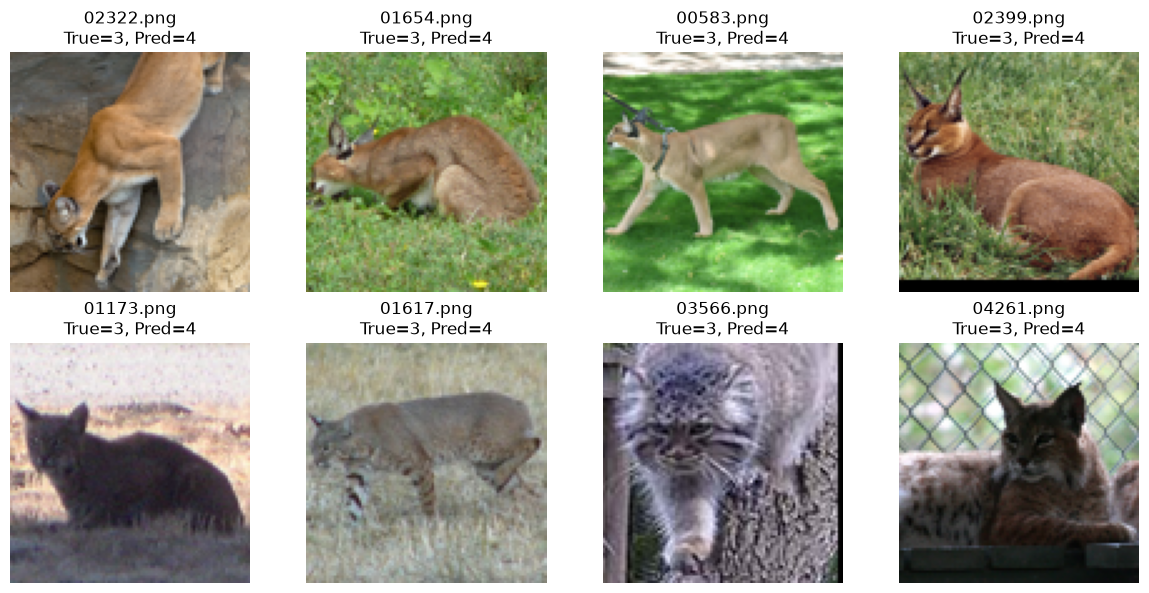

In [42]:
show_wrong_images(wrong_df, 3, 4)

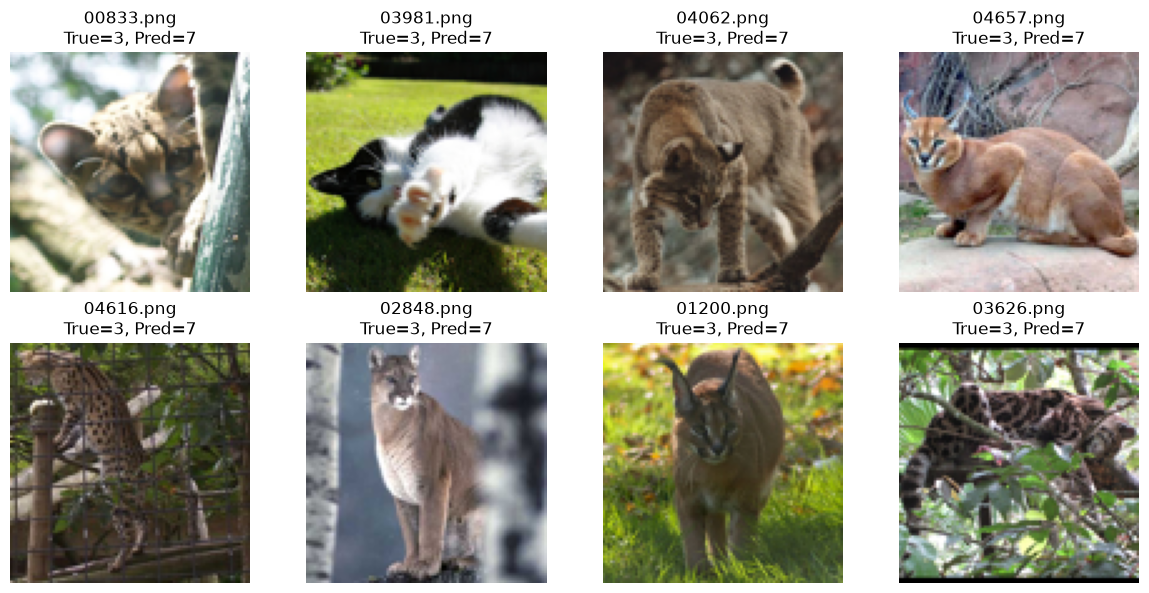

In [43]:
show_wrong_images(wrong_df, 3, 7)

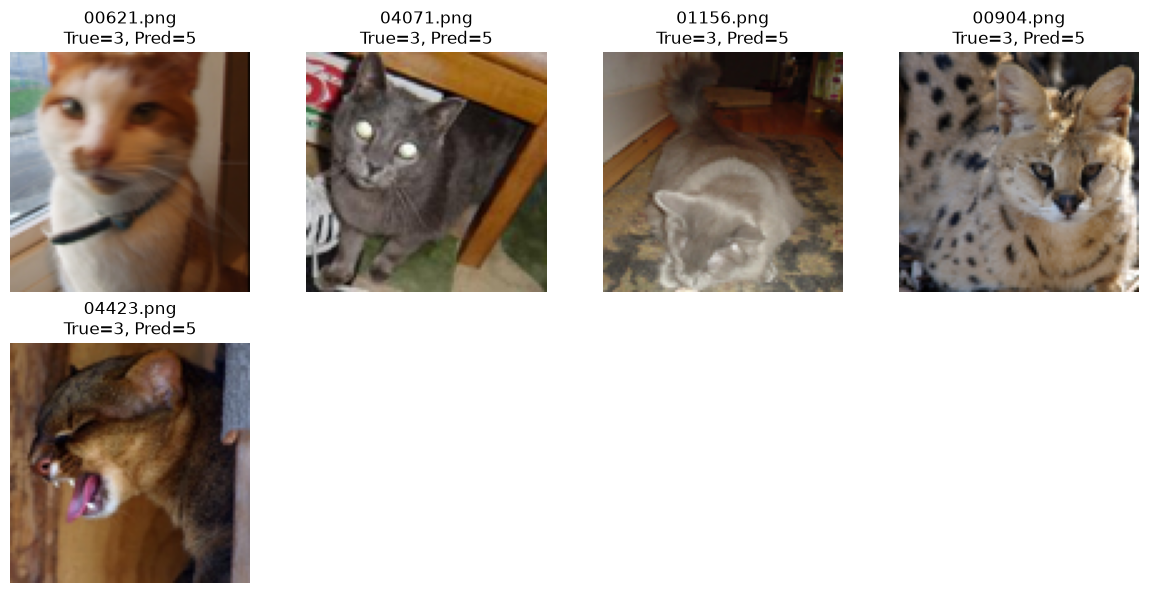

In [44]:
show_wrong_images(wrong_df, 3, 5)

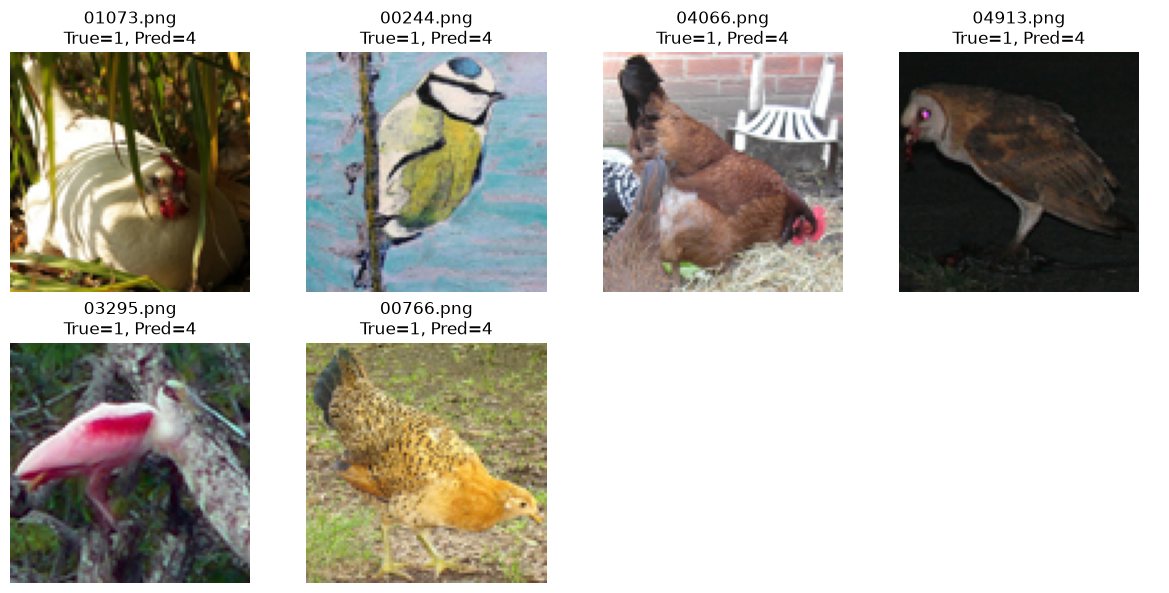

In [45]:
show_wrong_images(wrong_df, 1, 4)

In [60]:
# 오분류된 데이터 기준 증강 수정 (약화)
train_transform_after_weak =  transforms.Compose([
    # To-do: 증강 기법 적용
    v2.RandomCrop(96, padding=4),
    v2.RandomHorizontalFlip(p = 0.5),
    # v2.RandomRotation(8),
    v2.RandomRotation(30),
    v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
    v2.ToTensor(),
    v2.RandomErasing(p = 0.2, scale = (0.02, 0.08), ratio = (0.5, 2.0), inplace = False),
    v2.Normalize(mean = mean, std = std),
])


train_total_dataset_after_weak =  MyDataset(data_path, train=True, transform=train_transform_after_weak)

train_data_after_weak = Subset(train_total_dataset_after_weak, train_indices)

c:\Users\jjbyk\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
best = {
    "lr" : [0.00080],
    "wd" : [0.00170]}
best_model, best_val_acc, best_val_loss, best_epoch = run_Adam(use_amp= True, dataset_ver="weak",
    lr= best["lr"][0] , batch_size=64, weight_decay = best["wd"][0], epochs=100, label_smoothing = 0.05)
# epoch 100 | lr=0.0000012 | train_loss=0.3614 | train_acc=0.9760 | val_loss=0.8696 | val_acc=0.7920
# Best epoch=90 | best_train_acc=0.9707 | best_val_acc=0.8060 | best_val_loss=0.8524

  5%|▌         | 5/100 [00:40<12:50,  8.11s/it]

epoch   5 | lr=0.0007968 | train_loss=1.4870 | train_acc=0.4927 | val_loss=1.5895 | val_acc=0.4320


 10%|█         | 10/100 [01:21<12:18,  8.21s/it]

epoch  10 | lr=0.0007841 | train_loss=1.3431 | train_acc=0.5656 | val_loss=1.4712 | val_acc=0.5480


 15%|█▌        | 15/100 [02:02<11:38,  8.21s/it]

...

 90%|█████████ | 90/100 [12:21<01:22,  8.27s/it]

epoch  90 | lr=0.0000246 | train_loss=0.3720 | train_acc=0.9707 | val_loss=0.8524 | val_acc=0.8060


 95%|█████████▌| 95/100 [13:01<00:40,  8.05s/it]

epoch  95 | lr=0.0000081 | train_loss=0.3598 | train_acc=0.9778 | val_loss=0.8715 | val_acc=0.7920


epoch 100 | lr=0.0000012 | train_loss=0.3614 | train_acc=0.9760 | val_loss=0.8696 | val_acc=0.7920
Best epoch=90 | best_train_acc=0.9707 | best_val_acc=0.8060 | best_val_loss=0.8524


오분류 개수: 97
      total  correct  wrong  accuracy
true                                 
0        44       38      6  0.863636
1        52       36     16  0.692308
2        38       36      2  0.947368
3        56       29     27  0.517857
4        53       46      7  0.867925
5        53       39     14  0.735849
6        60       53      7  0.883333
7        52       47      5  0.903846
8        46       41      5  0.891304
9        46       38      8  0.826087
[[38  2  1  0  0  0  0  0  3  0]
 [ 1 36  0  2  6  3  0  4  0  0]
 [ 0  0 36  1  0  0  0  0  0  1]
 [ 0  3  0 29  8  5  2  8  0  1]
 [ 0  0  0  2 46  4  0  1  0  0]
 [ 0  1  0  3  0 39  4  6  0  0]
 [ 1  0  1  0  1  4 53  0  0  0]
 [ 0  3  0  0  0  1  1 47  0  0]
 [ 2  0  0  0  0  0  0  0 41  3]
 [ 1  1  2  0  0  0  1  0  3 38]]


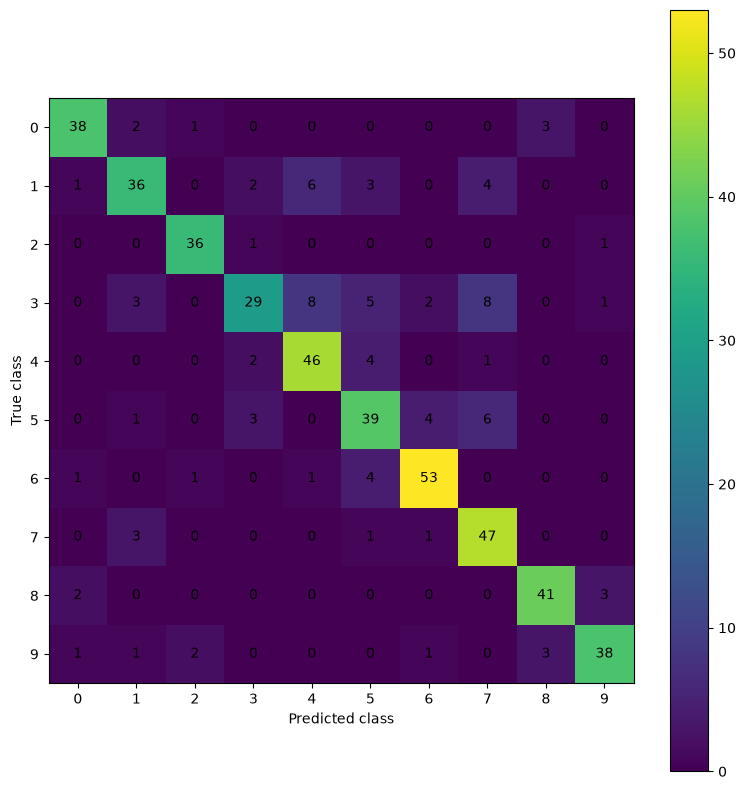

In [59]:
wrong_df = check_fails(best_model, analysis_val_loader)

# 기존 코드 보존

In [17]:
plain_transform = transforms.Compose([
    v2.ToTensor(),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

plain_dataset = MyDataset(
    data_path,
    train=True,
    transform=plain_transform
)

tiny_data = Subset(
    plain_dataset,
    train_indices.indices[:64]
)

tiny_loader = DataLoader(
    tiny_data,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

In [18]:
model = make_model()

opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

crit = nn.CrossEntropyLoss()

for ep in range(100):
    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for x, y in tiny_loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()

        outputs = model(x)
        loss = crit(outputs, y)

        loss.backward()
        opt.step()

        running_loss += loss.item() * y.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)

    if (ep + 1) % 10 == 0:
        print(
            f"epoch {ep+1:3d} | "
            f"loss={running_loss/total:.4f} | "
            f"acc={correct/total:.4f}"
        )

epoch  10 | loss=0.1164 | acc=1.0000
epoch  20 | loss=0.0082 | acc=1.0000
epoch  30 | loss=0.0019 | acc=1.0000
epoch  40 | loss=0.0008 | acc=1.0000
epoch  50 | loss=0.0005 | acc=1.0000
epoch  60 | loss=0.0003 | acc=1.0000
epoch  70 | loss=0.0003 | acc=1.0000
epoch  80 | loss=0.0002 | acc=1.0000
epoch  90 | loss=0.0002 | acc=1.0000
epoch 100 | loss=0.0002 | acc=1.0000


In [ ]:



# total_step = len(train_loader)
# for epoch in range(num_epochs):
#     total_loss = 0

#     pbar = tqdm(enumerate(train_loader), total=len(train_loader))

#     for i, (images, labels) in pbar:
#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = model(images)
#         loss = criterion(outputs, labels)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#         pbar.set_description(f'Epoch [{epoch+1}/{num_epochs}], Loss: {round(total_loss / (i+1),4)}')


#     model.eval()
#     with torch.no_grad():
#         correct = 0
#         total = 0
#         for images, labels in val_loader:
#             images = images.to(device)
#             labels = labels.to(device)
#             outputs = model(images)
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#         print(f'Accuracy of the model on the test images: {100 * correct / total} %')


Epoch [1/5], Loss: 2.2763: 100%|██████████| 36/36 [00:09<00:00,  3.63it/s]


Accuracy of the model on the test images: 13.0 %


Epoch [2/5], Loss: 2.171: 100%|██████████| 36/36 [00:06<00:00,  5.90it/s]


Accuracy of the model on the test images: 21.6 %


Epoch [3/5], Loss: 1.9326: 100%|██████████| 36/36 [00:06<00:00,  5.60it/s]


Accuracy of the model on the test images: 28.2 %


Epoch [4/5], Loss: 1.8175: 100%|██████████| 36/36 [00:06<00:00,  5.91it/s]


Accuracy of the model on the test images: 30.2 %


Epoch [5/5], Loss: 1.6632: 100%|██████████| 36/36 [00:06<00:00,  5.56it/s]


Accuracy of the model on the test images: 32.4 %


# Evaluation (Test)

In [ ]:
# len(val_loader.dataset)
# len(test_loader.dataset)

500

In [ ]:
# correct = 0
# total = len(val_loader.dataset)

# with torch.no_grad():
#     for images, labels in val_loader:
#         images = images.to(device)
#         labels = labels.to(device)
#         outputs = model(images)
#         _, predicted = torch.max(outputs, 1)
#         correct += torch.sum((predicted == labels)).item()

# print(f'Accuracy : {100 * correct / total} %')


Accuracy : 32.4 %


# Make SubmitFile

In [ ]:
# import pandas as pd

# # 제출 파일 submission.csv 생성
# outputs = {
#     'Id': [],
#     'Prediction': []
# }

# for images, id in tqdm(test_loader):
#     model.eval()
#     with torch.no_grad():
#         output = model(images.to(device))
#         _, predicted = torch.max(output, 1)
#         outputs['Prediction'] += predicted.tolist()
#         outputs['Id'] += id

# df = pd.DataFrame(outputs)

# df.to_csv('submission.csv', index=False, columns=['Id', 'Prediction'])

100%|██████████| 63/63 [00:08<00:00,  7.67it/s]


In [ ]:
# # 제출파일 다운로드
# from google.colab import files

# file_path = "submission.csv"
# files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>